**Dados do projeto**

https://github.com/alura-cursos/Dataviz_R_Projeto_Inicial

**Importando os pacotes do projeto**

In [82]:
library(ggplot2)
library(dplyr)
library(readr)
library(lubridate)
library(scales)

# Conhecendo os dados

**Obtendo dados**

In [83]:
url_clientes = "/content/zoop_clientes.csv"
url_vendas = "/content/zoop_vendas.csv"

In [84]:
vendas <- read_csv(url_vendas, show_col_types = F)
head(vendas)

ID_compra,data,horario,categoria,preco_unitario,quantidade,frete,metodo_pagamento
<dbl>,<date>,<time>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
6,2023-01-03,20:40:00,Tecnologia,899.19,4,713.26,Boleto
5,2023-01-03,21:48:00,Casa/Móveis,115.90,1,0.00,PIX
9,2023-01-03,17:08:00,Beleza/Saúde,68.90,2,13.78,Crédito
4,2023-01-03,14:29:00,Casa/Móveis,80.90,5,40.45,PIX
8,2023-01-03,18:02:00,Beleza/Saúde,165.00,4,0.00,PIX
2,2023-01-03,18:42:00,Tecnologia,2028.48,5,1724.37,PIX


In [85]:
clientes <- read_csv(url_clientes, show_col_types = F)
glimpse(clientes)

Rows: 6,169
Columns: 9
$ ID_compra        <dbl> 904, 4613, 5579, 2405, 2485, 756, 3020, 2390, 3957, 5…
$ ID_cliente       <dbl> 8972, 5120, 1847, 2846, 2715, 9555, 3793, 4903, 3413,…
$ cidade           <chr> "Natal", "São Paulo", "São Paulo", "São Paulo", "Salv…
$ uf               <chr> "Rio Grande do Norte", "São Paulo", "São Paulo", "São…
$ regiao           <chr> "Nordeste", "Sudeste", "Sudeste", "Sudeste", "Nordest…
$ idade            <dbl> 49, 49, 24, 38, 30, 46, 32, 26, 30, 28, 25, 31, 40, 4…
$ sexo_biologico   <chr> "Masculino", "Feminino", "Feminino", "Feminino", "Fem…
$ cashback         <chr> "Não", "Não", "Não", "Sim", "Não", "Não", "Sim", "Não…
$ avaliacao_compra <dbl> 9, 9, 8, 7, 10, 7, 9, 9, 10, 8, 7, 10, 9, 8, 8, 7, 10…


**Tratando os dados**

* Compreender a estrutura dos dados;
* Avaliar a necessidade de adicionar dados;
* Verificar tipos e valores;
* Incluir coluna, se necessário;

**Alterando colunas do tipo "chr" para "fct":**

Ao converter chr para factor, podemos ordenar os níveis da variável categórica na ordem desejada, facilitando sua interpretação.

**Ajustando tabela de vendas:**

In [86]:
vendas

ID_compra,data,horario,categoria,preco_unitario,quantidade,frete,metodo_pagamento
<dbl>,<date>,<time>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
6,2023-01-03,20:40:00,Tecnologia,899.19,4,713.26,Boleto
5,2023-01-03,21:48:00,Casa/Móveis,115.90,1,0.00,PIX
9,2023-01-03,17:08:00,Beleza/Saúde,68.90,2,13.78,Crédito
4,2023-01-03,14:29:00,Casa/Móveis,80.90,5,40.45,PIX
8,2023-01-03,18:02:00,Beleza/Saúde,165.00,4,0.00,PIX
2,2023-01-03,18:42:00,Tecnologia,2028.48,5,1724.37,PIX
3,2023-01-03,23:47:00,Supermercado,84.90,5,0.00,Crédito
1,2023-01-03,00:13:00,Eletrodomésticos,2169.98,1,138.64,PIX
7,2023-01-03,17:40:00,Livros,75.90,5,18.98,Crédito


In [87]:
vendas <- vendas %>%
  mutate_if(is.character, as.factor)

head(vendas)

ID_compra,data,horario,categoria,preco_unitario,quantidade,frete,metodo_pagamento
<dbl>,<date>,<time>,<fct>,<dbl>,<dbl>,<dbl>,<fct>
6,2023-01-03,20:40:00,Tecnologia,899.19,4,713.26,Boleto
5,2023-01-03,21:48:00,Casa/Móveis,115.90,1,0.00,PIX
9,2023-01-03,17:08:00,Beleza/Saúde,68.90,2,13.78,Crédito
4,2023-01-03,14:29:00,Casa/Móveis,80.90,5,40.45,PIX
8,2023-01-03,18:02:00,Beleza/Saúde,165.00,4,0.00,PIX
2,2023-01-03,18:42:00,Tecnologia,2028.48,5,1724.37,PIX


In [88]:
vendas <- vendas %>%
  mutate(total = preco_unitario * quantidade + frete )

head(vendas)

ID_compra,data,horario,categoria,preco_unitario,quantidade,frete,metodo_pagamento,total
<dbl>,<date>,<time>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>
6,2023-01-03,20:40:00,Tecnologia,899.19,4,713.26,Boleto,4310.02
5,2023-01-03,21:48:00,Casa/Móveis,115.90,1,0.00,PIX,115.90
9,2023-01-03,17:08:00,Beleza/Saúde,68.90,2,13.78,Crédito,151.58
4,2023-01-03,14:29:00,Casa/Móveis,80.90,5,40.45,PIX,444.95
8,2023-01-03,18:02:00,Beleza/Saúde,165.00,4,0.00,PIX,660.00
2,2023-01-03,18:42:00,Tecnologia,2028.48,5,1724.37,PIX,11866.77


**Ajustando tabela de clientes:**

In [89]:
clientes

ID_compra,ID_cliente,cidade,uf,regiao,idade,sexo_biologico,cashback,avaliacao_compra
<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
904,8972,Natal,Rio Grande do Norte,Nordeste,49,Masculino,Não,9
4613,5120,São Paulo,São Paulo,Sudeste,49,Feminino,Não,9
5579,1847,São Paulo,São Paulo,Sudeste,24,Feminino,Não,8
2405,2846,São Paulo,São Paulo,Sudeste,38,Feminino,Sim,7
2485,2715,Salvador,Bahia,Nordeste,30,Feminino,Não,10
756,9555,João Pessoa,Paraíba,Nordeste,46,Feminino,Não,7
3020,3793,Brasília,Distrito Federal,Centro-Oeste,32,Masculino,Sim,9
2390,4903,São Paulo,São Paulo,Sudeste,26,Masculino,Não,9
3957,3413,Salvador,Bahia,Nordeste,30,Feminino,Não,10


In [90]:
clientes <- clientes %>%
  mutate_if(is.character, as.factor)

head(vendas)

ID_compra,data,horario,categoria,preco_unitario,quantidade,frete,metodo_pagamento,total
<dbl>,<date>,<time>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>
6,2023-01-03,20:40:00,Tecnologia,899.19,4,713.26,Boleto,4310.02
5,2023-01-03,21:48:00,Casa/Móveis,115.90,1,0.00,PIX,115.90
9,2023-01-03,17:08:00,Beleza/Saúde,68.90,2,13.78,Crédito,151.58
4,2023-01-03,14:29:00,Casa/Móveis,80.90,5,40.45,PIX,444.95
8,2023-01-03,18:02:00,Beleza/Saúde,165.00,4,0.00,PIX,660.00
2,2023-01-03,18:42:00,Tecnologia,2028.48,5,1724.37,PIX,11866.77


**Construindo primeiro visual**

* data - Camada de dados;
* aesthetics - estética;
* geometries - geometria, elemento que estamos colocando no visual;
* statistics - Representação dos dados para facilitar a compreensão;
* coordinates - o espaço em que o visual será construído;
* themes - Os recursos externos aos dados para refinar o visual;
* facets - Plotagem de dados em pequenos múltiplos (Segregação de dados);


**1 - Desenhando a base:**

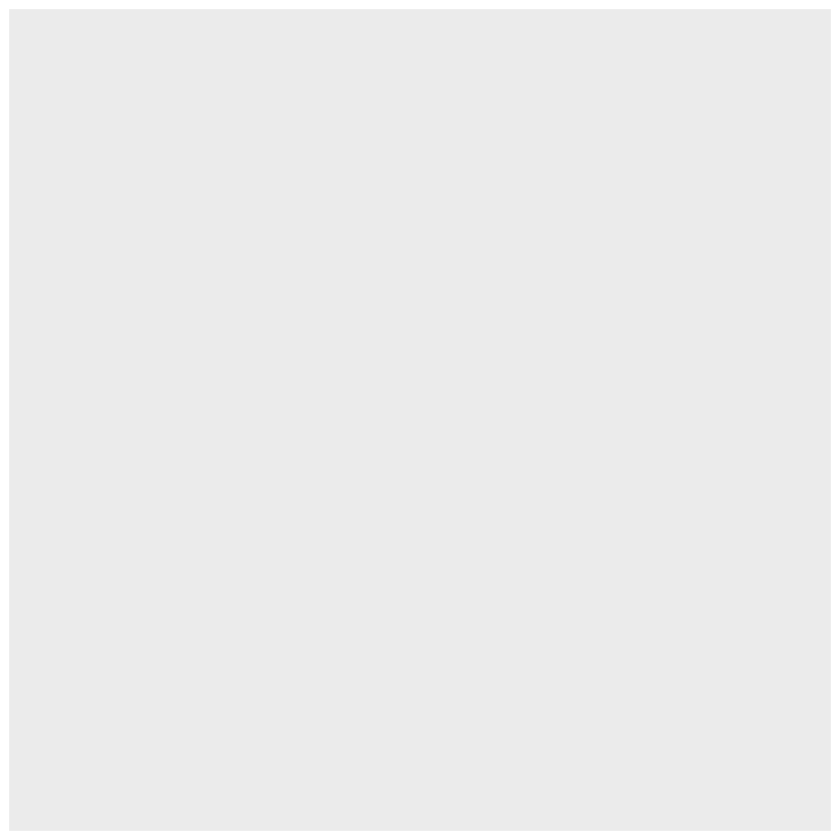

In [91]:
ggplot(vendas)

** 2 - Escolher a estética do gráfico (dimensão visual):**

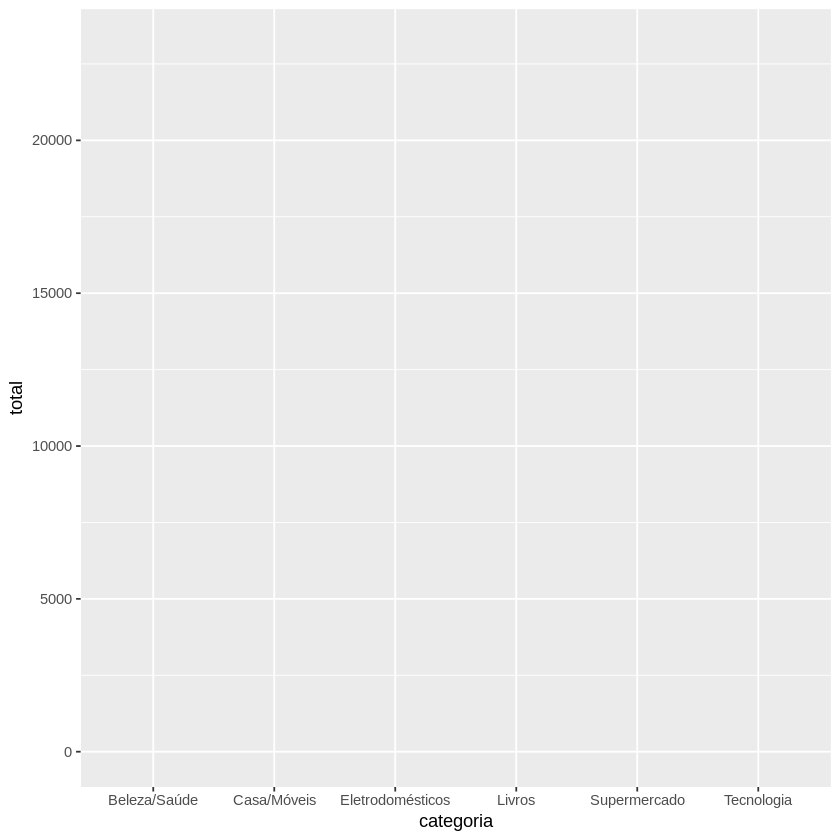

In [92]:
ggplot(vendas, aes(x = categoria, y = total))

**3 - Definir o elemento geométrico (tipo do visual):**

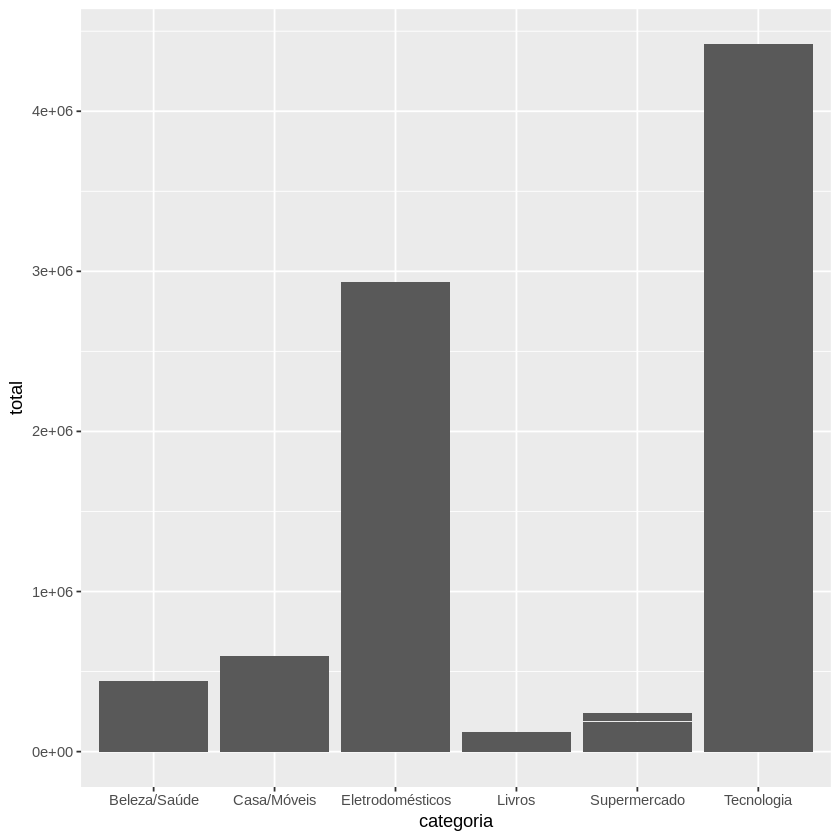

In [93]:
ggplot(vendas, aes(x = categoria, y = total)) +
  geom_col()

**Sintaxe básica na criação de um gráfico:**
ggplot(data = dados, aex(x = Var_1, y = Var_2)) + geom_*tipo_grafico()*

**Para saber mais: elementos gramaticais do ggplot2**

O pacote [ggplot2](https://ggplot2.tidyverse.org/reference/index.html) trabalha com a criação de visualização de dados em camadas. Ou seja, para construir um gráfico, nós precisamos montá-los aos poucos adicionando os recursos camada por camada.

O conceito de elementos gramaticais de gráficos foi criado pelo estatístico e escritor Leland Wilkinson que apresentou uma série de regras e estruturas que constituem as camadas e recursos de um visual significativo. Em resumo, ele nos diz que um gráfico é um mapeamento de dados para atributos estéticos (cor, forma, tamanho) de objetos geométricos (pontos, linhas, barras). O gráfico também pode conter transformações estatísticas dos dados e é desenhado em um sistema de coordenadas específico. Ao todo, temos 7 elementos gramaticais no **ggplot2**:

**data:**	Os dados que serão utilizados para a construção do visual;

**aesthetics:**	A dimensão visual dos dados (coordenadas e elementos estéticos);

**geometries:**	Os elementos visuais utilizados a partir dos dados;

**statistics:**	Representação dos dados para facilitar a compreensão;

**coordinates:**	O espaço em que o visual será construído;

**themes:**	Os recursos externos aos dados para refinar o visual;

**facets:**	Plotagem de dados em pequenos múltiplos (segregação de dados);


Sendo 3 deles essenciais, como observamos durante a aula: Data, Aesthetics e Geometries.

Vamos entender um pouco mais sobre os outros? Para isso, utilizaremos o pacote de dados gapminder que é uma base bastante utilizada por quem está iniciando os estudos na linguagem R e pode ser carregada facilmente no Posit Cloud ou RStudio. Iniciaremos construindo um gráfico de dispersão (pontos) com a relação entre a Expectativa de vida (lifeExp) e o PIB per capita em dólares (gdpPerCap). Experimente o seguinte código:

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



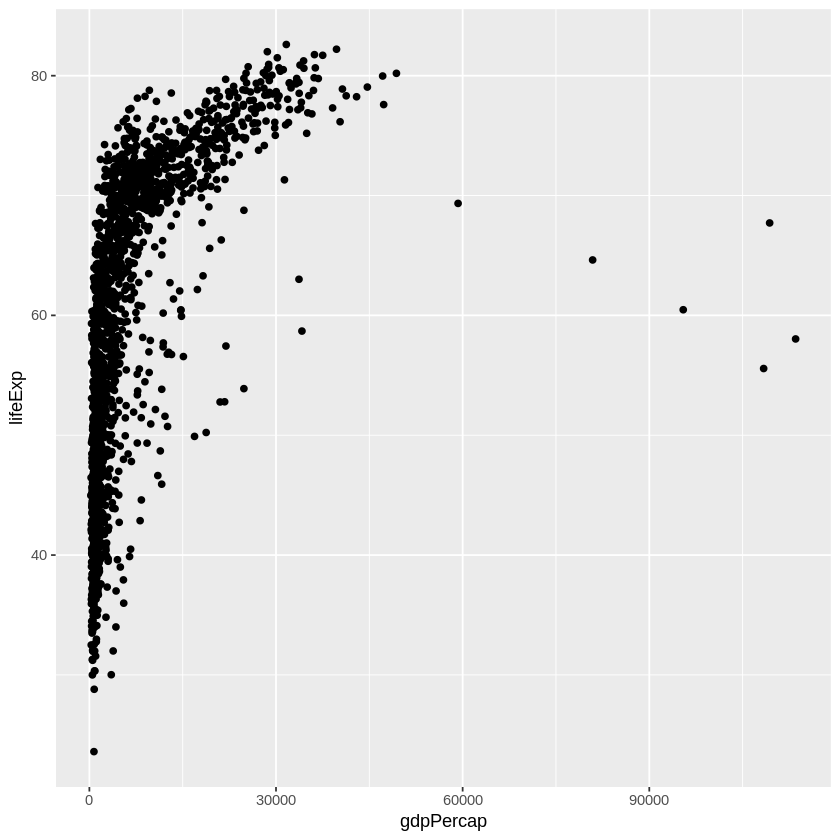

In [94]:
install.packages("gapminder")
library(gapminder)
library(ggplot2)

ggplot(gapminder, aes(x=gdpPercap, y=lifeExp)) +
  geom_point()

**Statistics**

Este elemento refere-se à representação de informações estatísticas sobre os dados, como contagem, média, variância, entre outros, para ajudar no entendimento dos dados. Elas são calculadas antes de o gráfico ser desenhado e são opcionais. Podemos, por exemplo, atualizar nosso gráfico adicionando uma linha de tendência linear ao gráfico de dispersão.

`geom_smooth()` using formula = 'y ~ x'


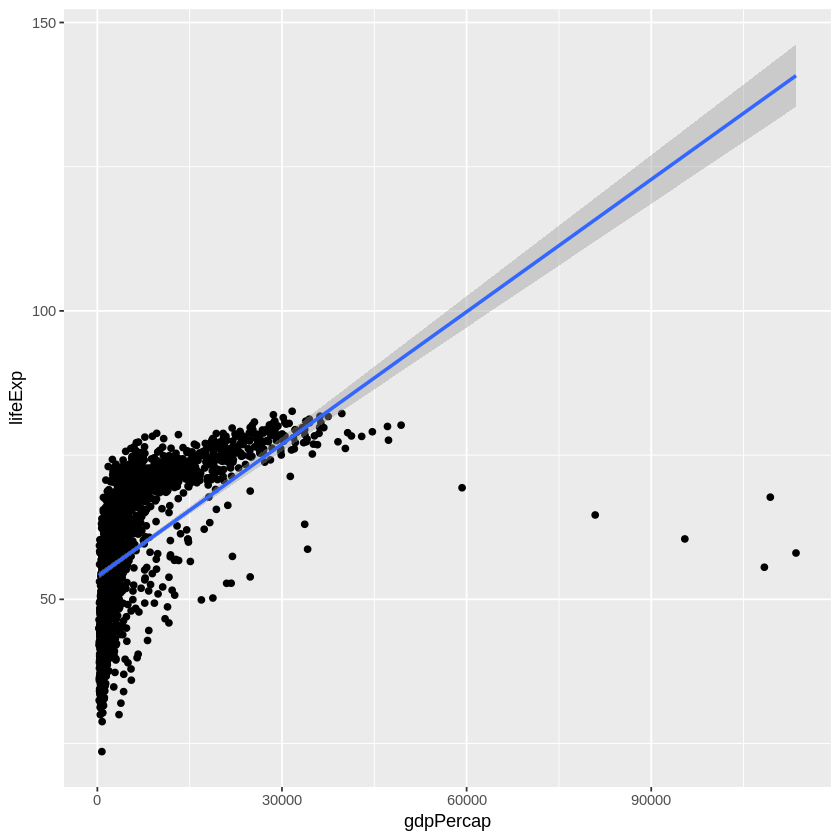

In [95]:
ggplot(gapminder, aes(x=gdpPercap, y=lifeExp)) +
  geom_point() +
  geom_smooth(method = "lm")

**Coordinates**

Este elemento refere-se ao espaço no qual os dados são plotados (por exemplo, coordenadas cartesianas, polares ou logarítmicas). Os gráficos mais populares, como gráficos de linha e de barras, são desenhados usando coordenadas cartesianas. Este também é um elemento opcional.

Podemos, por exemplo, ajustar o nosso gráfico para que o eixo X, que tem valores muito grandes, esteja em coordenadas logarítmicas.

`geom_smooth()` using formula = 'y ~ x'


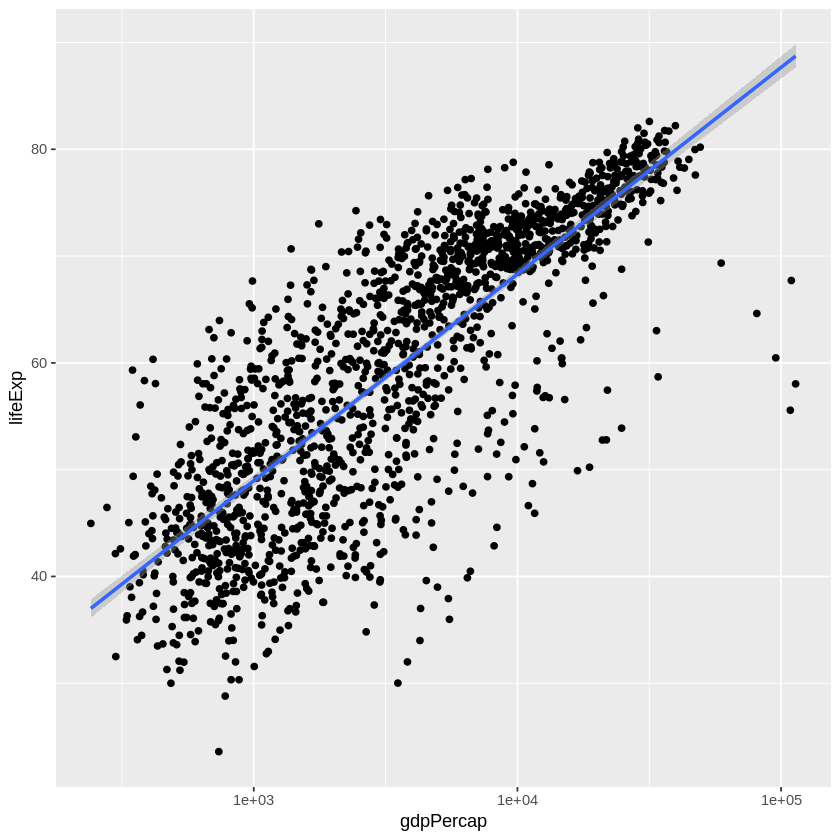

In [96]:
ggplot(gapminder, aes(x=gdpPercap, y=lifeExp)) +
  geom_point() +
  geom_smooth(method = "lm") +
  scale_x_log10()

**Facets**

O Faceting refere-se a divisão dos dados em vários subconjuntos, exibindo-os em uma figura. Cada gráfico mostra um subconjunto diferente dos dados. Este também é um elemento opcional e é bastante útil para comparar subgrupos. Podemos, por exemplo, ajustar o nosso gráfico e criar um conjunto separado de gráficos para cada continente.

`geom_smooth()` using formula = 'y ~ x'


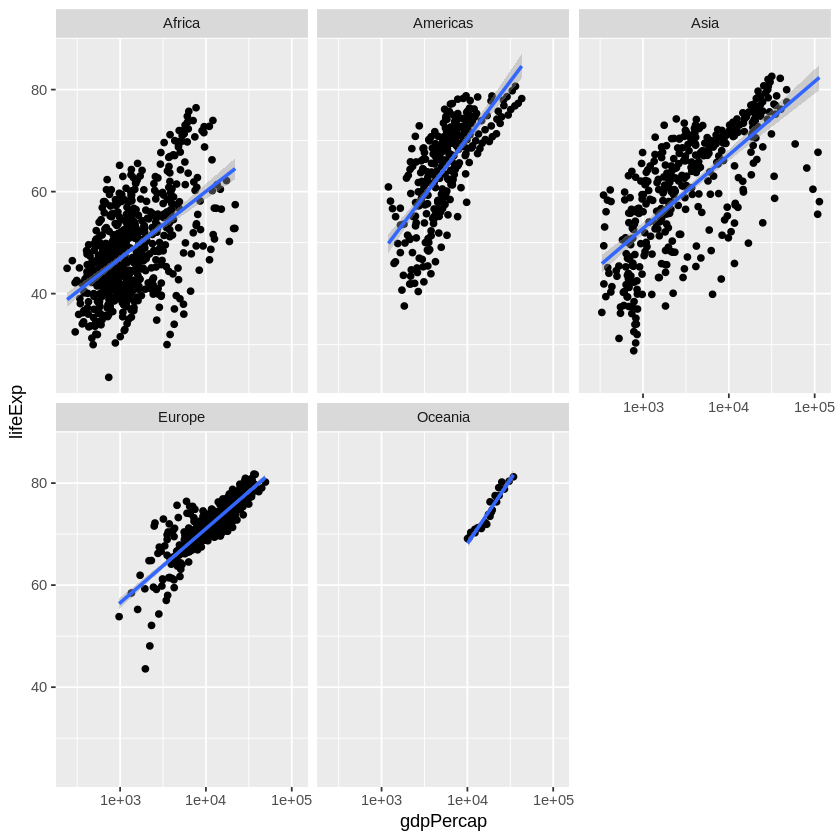

In [97]:
ggplot(gapminder, aes(x=gdpPercap, y=lifeExp)) +
  geom_point() +
  geom_smooth(method = "lm") +
  scale_x_log10() +
  facet_wrap(~continent)

**Themes**

Por fim, nós temos o elemento gramatical dos temas. Eles são utilizados para alterar a aparência de elementos que não são dados. Os temas permitem que você crie uma identidade visual específica usando fontes, cores e outros elementos de design. Este também é um elemento opcional e ajuda muito na estilização do seu visual. Vamos usar um tema pré-definido e alterar o nosso visual.

`geom_smooth()` using formula = 'y ~ x'


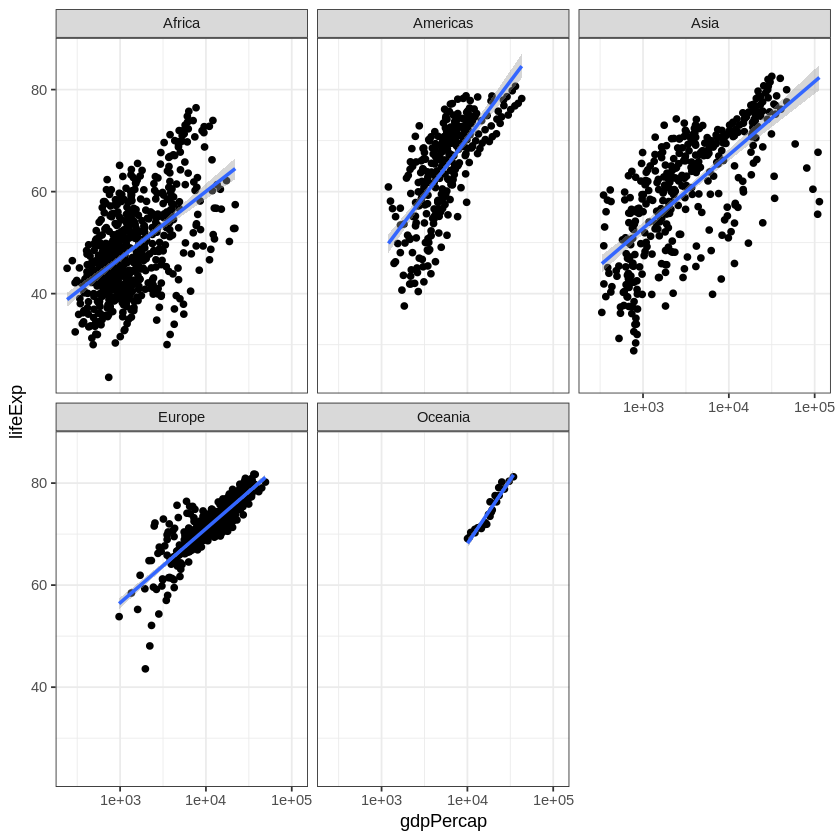

In [98]:
ggplot(gapminder, aes(x=gdpPercap, y=lifeExp)) +
  geom_point() +
  geom_smooth(method = "lm") +
  scale_x_log10() +
  facet_wrap(~continent) +
  theme_bw()

A associação de um ou mais destes elementos pode deixar o nosso visual ainda mais interessante, focando no que queremos apresentar. Saímos de simples gráficos, associando todos os dados, para gráficos que permitem realizar comparações entre os dados em diferentes continentes.

# Explorando dados dos clientes

**Distribuindo dados de uma única variável**

In [99]:
clientes %>%
  count(ID_cliente, sort=T)

ID_cliente,n
<dbl>,<int>
5267,7
4421,6
5145,6
9864,6
1442,5
6698,5
9363,5
1025,4
1172,4


In [100]:
clientes_unicos <- clientes %>%
  distinct(ID_cliente, .keep_all = T)

clientes_unicos

ID_compra,ID_cliente,cidade,uf,regiao,idade,sexo_biologico,cashback,avaliacao_compra
<dbl>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<fct>,<fct>,<dbl>
904,8972,Natal,Rio Grande do Norte,Nordeste,49,Masculino,Não,9
4613,5120,São Paulo,São Paulo,Sudeste,49,Feminino,Não,9
5579,1847,São Paulo,São Paulo,Sudeste,24,Feminino,Não,8
2405,2846,São Paulo,São Paulo,Sudeste,38,Feminino,Sim,7
2485,2715,Salvador,Bahia,Nordeste,30,Feminino,Não,10
756,9555,João Pessoa,Paraíba,Nordeste,46,Feminino,Não,7
3020,3793,Brasília,Distrito Federal,Centro-Oeste,32,Masculino,Sim,9
2390,4903,São Paulo,São Paulo,Sudeste,26,Masculino,Não,9
3957,3413,Salvador,Bahia,Nordeste,30,Feminino,Não,10


Como está distribuído o público por idade?

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


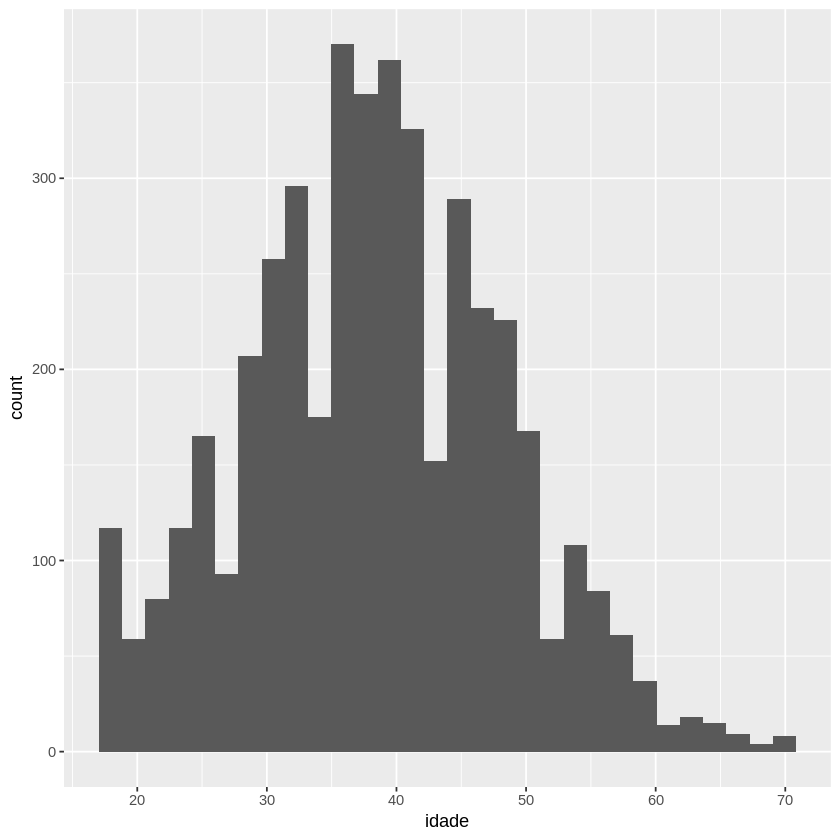

In [101]:
ggplot(clientes_unicos, aes(idade)) +
  geom_histogram()

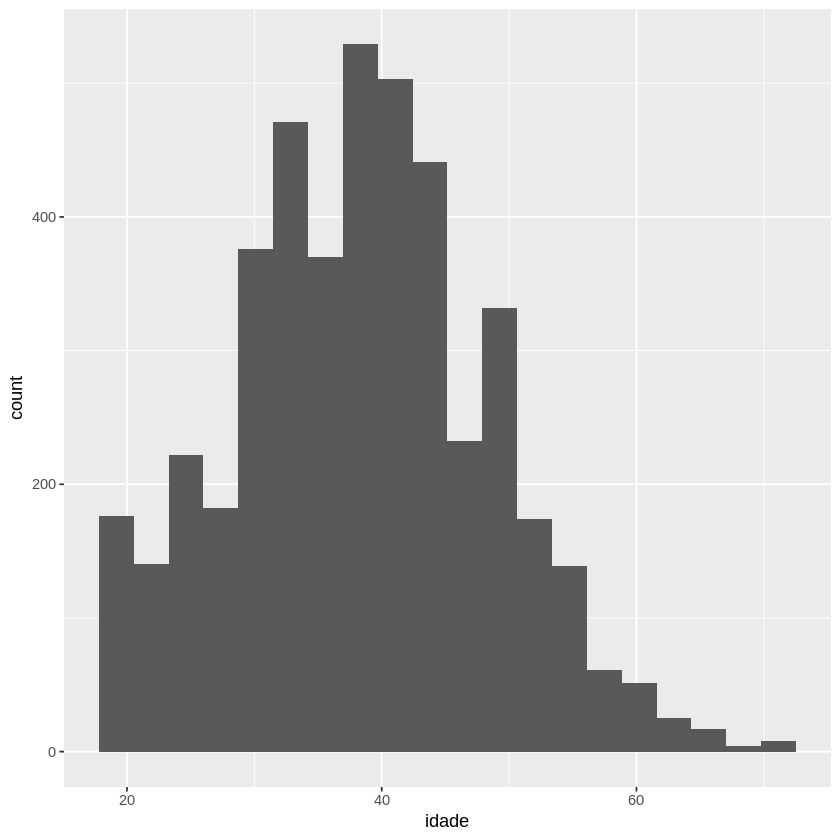

In [102]:
ggplot(clientes_unicos, aes(idade)) +
  geom_histogram(bins=20)

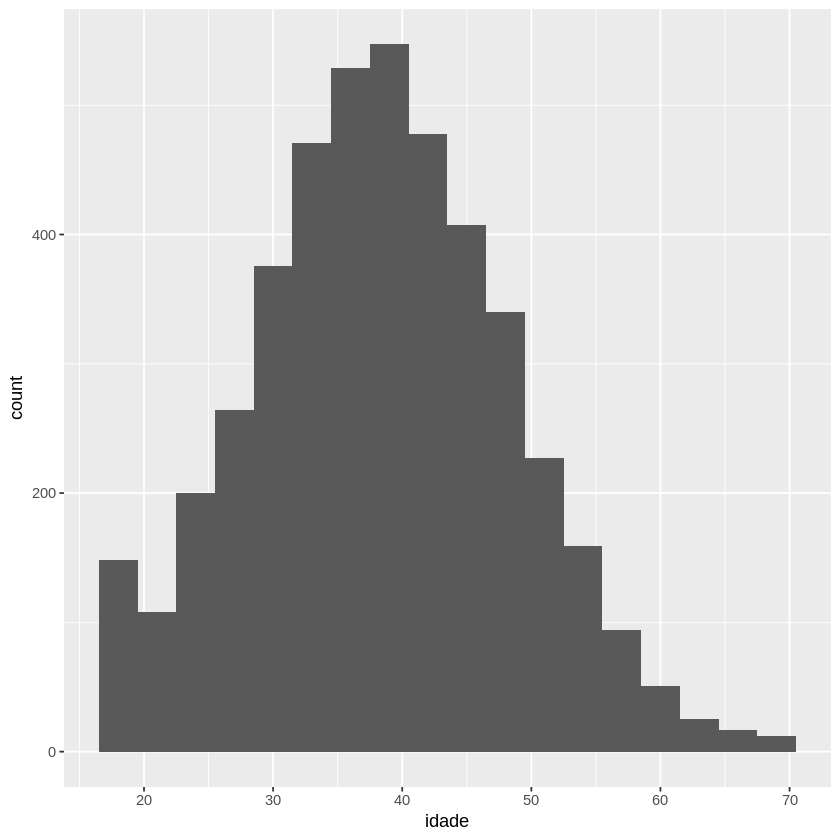

In [103]:
ggplot(clientes_unicos, aes(idade)) +
  geom_histogram(binwidth = 3)

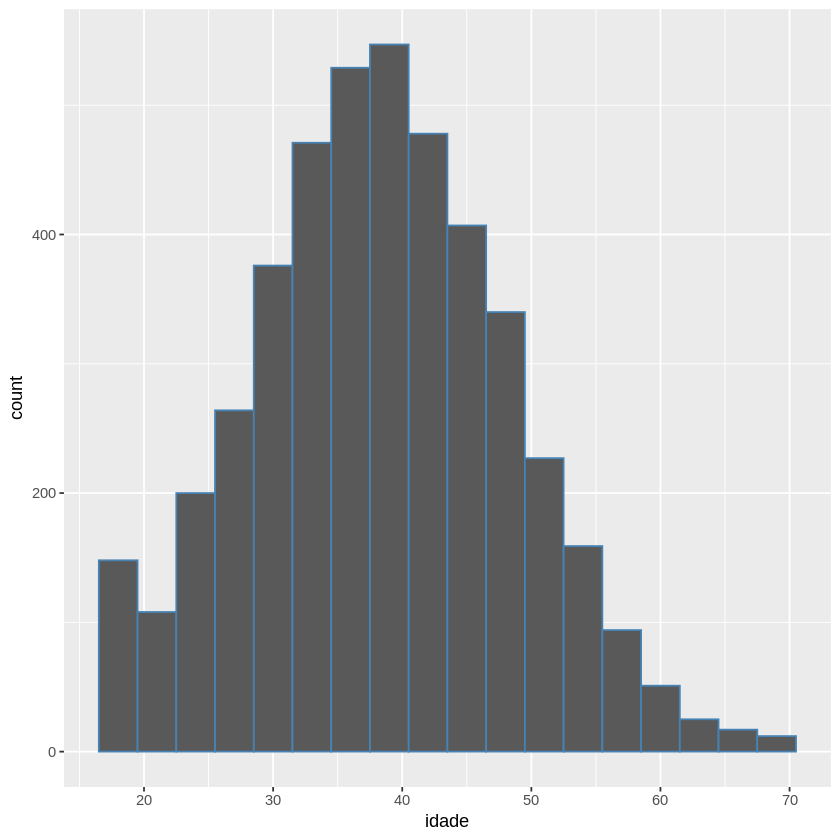

In [104]:
ggplot(clientes_unicos, aes(idade)) +
  geom_histogram(binwidth = 3, color="steelblue")

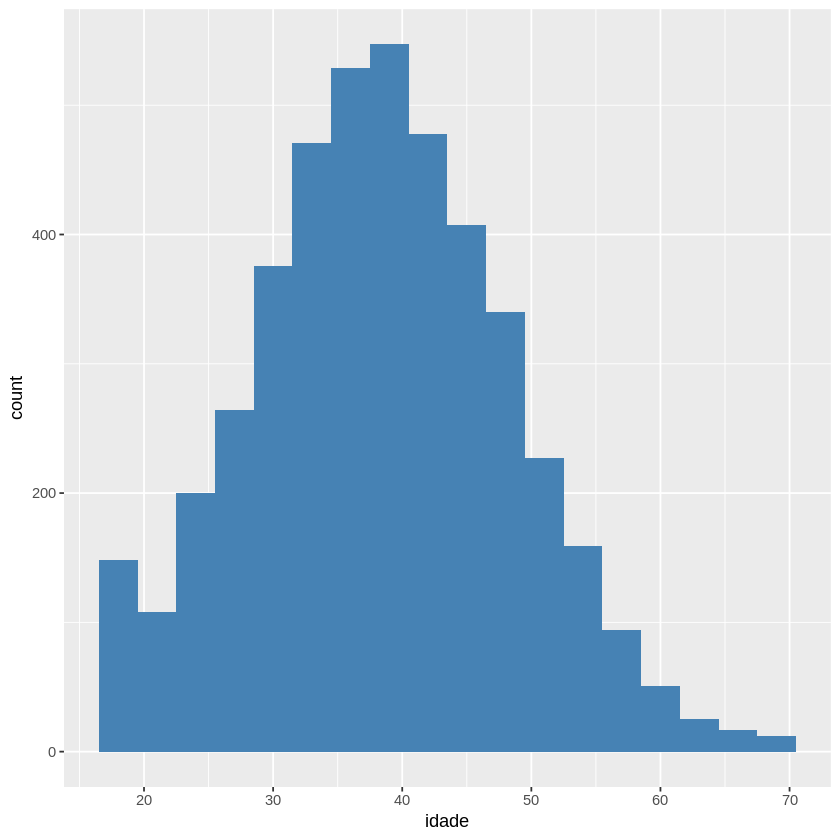

In [105]:
ggplot(clientes_unicos, aes(idade)) +
  geom_histogram(binwidth = 3, fill="steelblue")

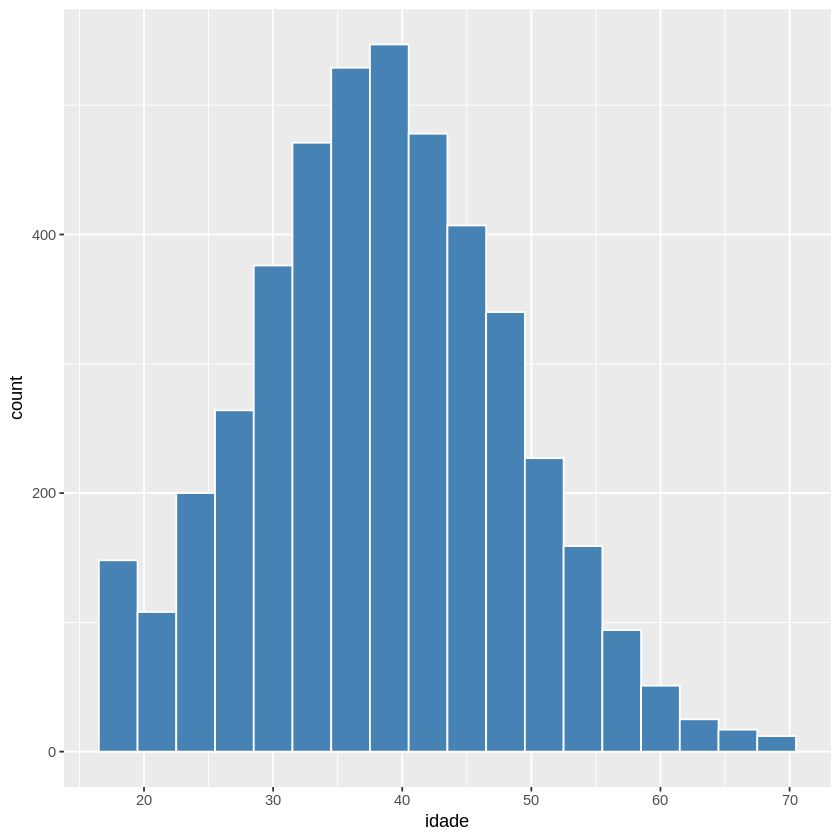

In [106]:
ggplot(clientes_unicos, aes(idade)) +
  geom_histogram(binwidth = 3, fill="steelblue", color="white")

**Distribuíndo dados por categoria**

Distribuição dos dados por idade e região

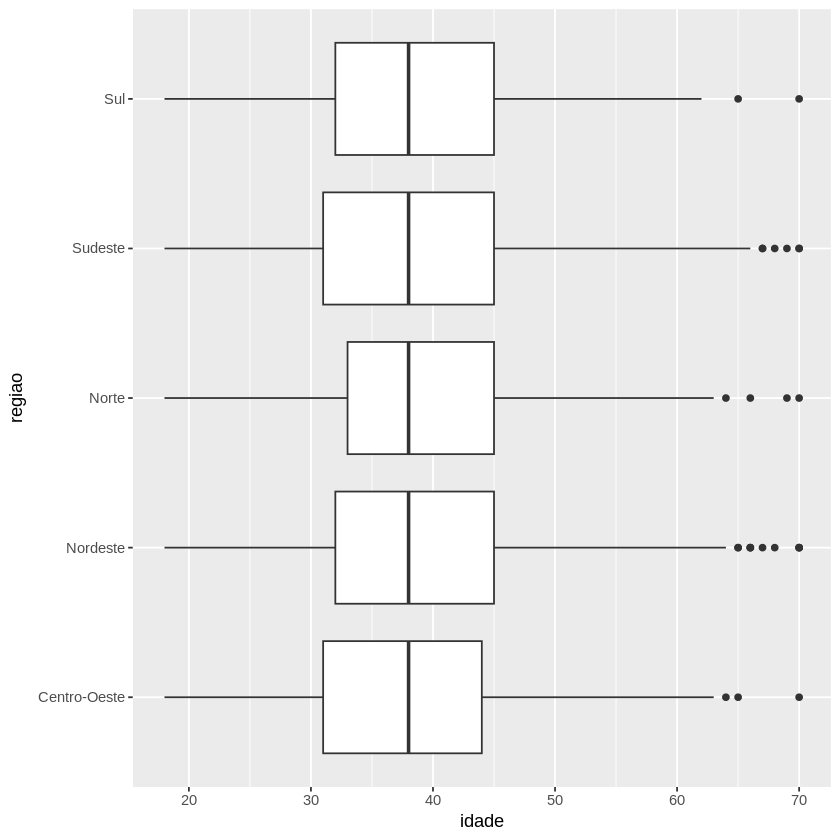

In [107]:
ggplot(clientes_unicos) +
  geom_boxplot(aes(x = idade, y = regiao))

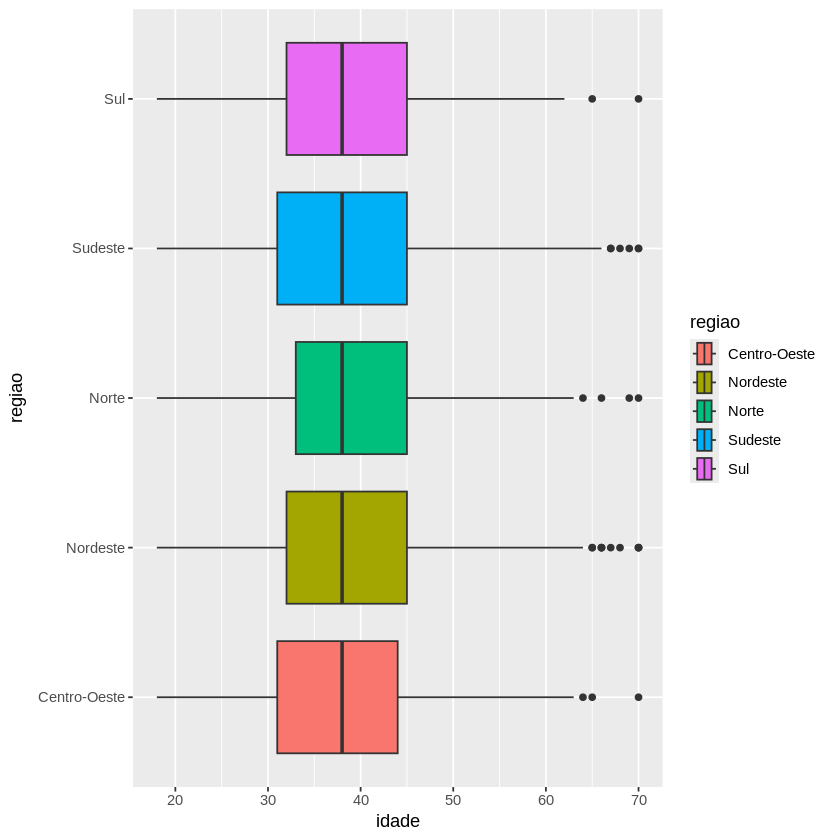

In [108]:
ggplot(clientes_unicos) +
  geom_boxplot(aes(x = idade, y = regiao, fill = regiao))

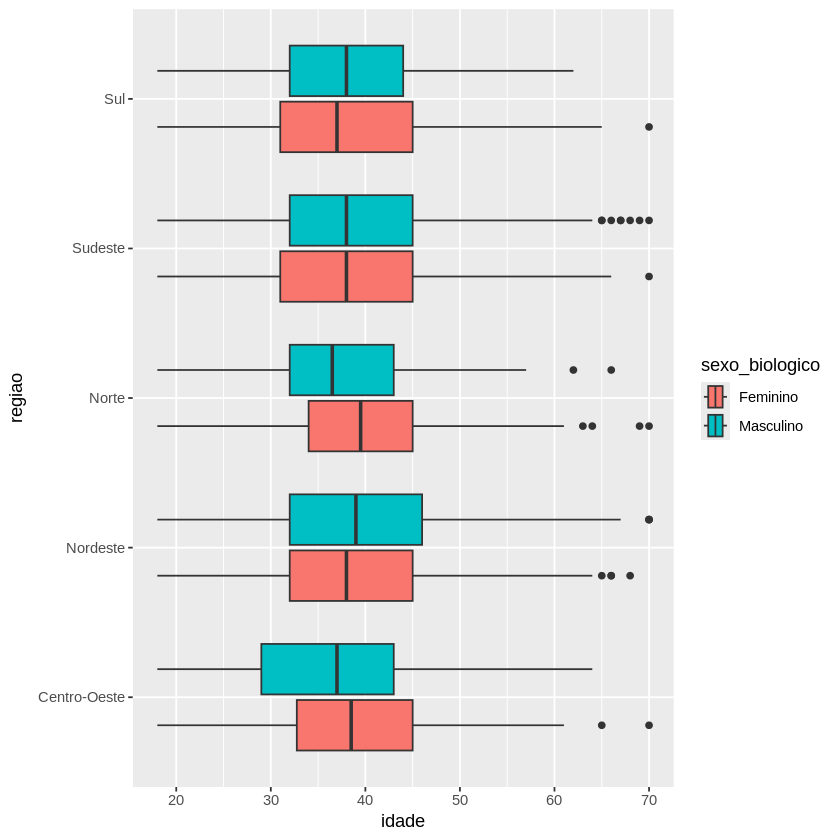

In [109]:
ggplot(clientes_unicos) +
  geom_boxplot(aes(x = idade, y = regiao, fill = sexo_biologico))

**Compondo dados**

Identificando clientes que utilizam chasback por região

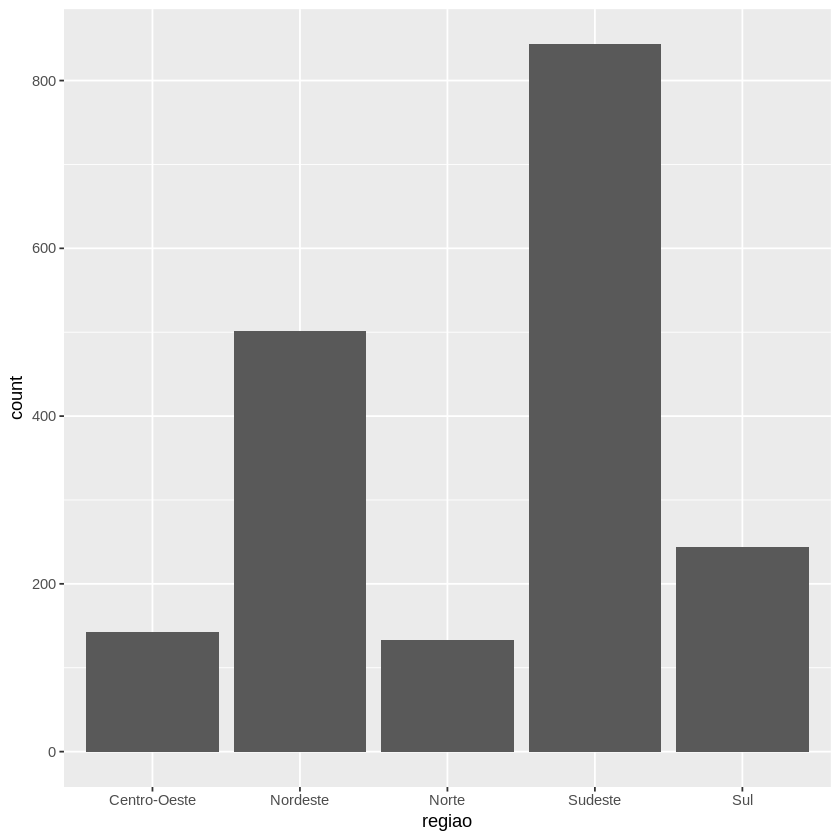

In [110]:
clientes_unicos %>% filter(cashback == "Sim") %>%
  ggplot(aes(x=regiao)) +
  geom_bar()

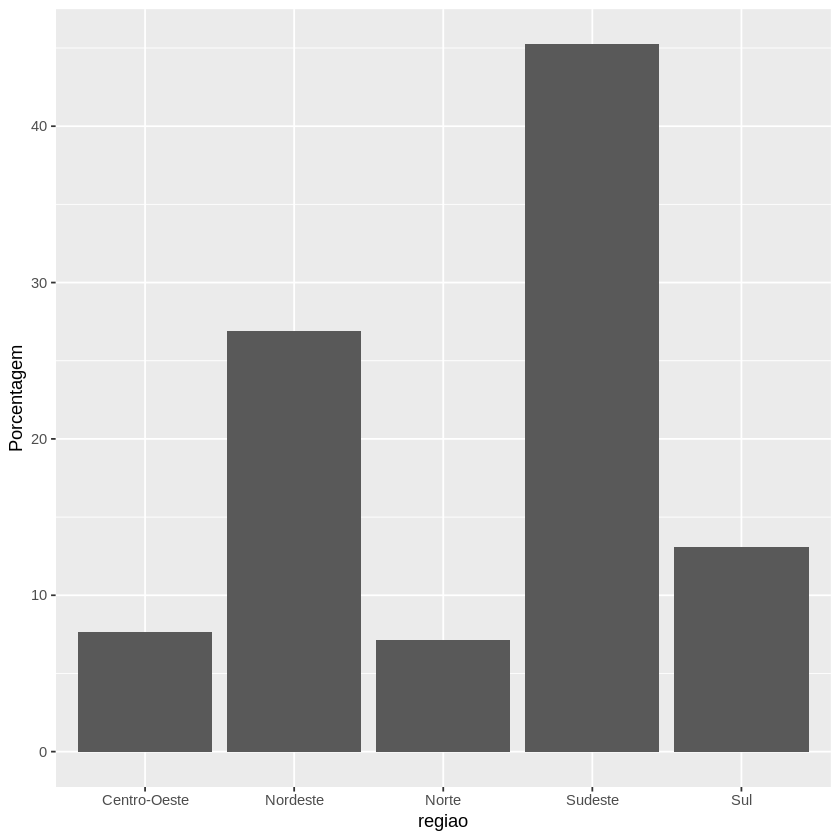

In [111]:
clientes_unicos %>% filter(cashback == "Sim") %>%
  ggplot(aes(x=regiao)) +
  geom_bar(aes(y = after_stat(100 * count/sum(count)))) +
  labs(y = "Porcentagem")

**Para saber mais: utilizando stat_summary()**

Quando utilizamos visualizações de dados para comunicar informações ou gerar insights, queremos deixar bastante claro a informação que queremos transmitir. Por exemplo, se descobrimos que grupos possuem diferenças significativas entre si em um determinado cenário, podemos querer mostrar esse resultado por meio de uma amostra.

Tradicionalmente, usamos a média ou a mediana de uma variável para fazer isso. Esses cálculos estatísticos ajudam nosso público a comparar variáveis categóricas, como grupos, com valores distintos. Pense na comparação da expectativa de vida entre continentes.

Temos diversas formas de representar esta e outras situações por meio do ggplot2. Uma delas é utilizando a função stat_summary(), que permite agregar dados e calcular estatísticas resumidas, como média, mediana, soma, entre outras, para exibir em um gráfico. Essa função é bastante útil quando desejamos representar um resumo estatístico dos dados, ao invés de mostrar todos os pontos individuais.

**Como funciona o stat_summary() e onde pode ser utilizado?**

O stat_summary() permite adicionar camadas de resumos estatísticos aos gráficos, como barras de erro, linhas de tendência ou até mesmo pontos representando médias ou medianas. Ele é flexível e permite definir tanto a função de resumo quanto a função do elemento geométrico (geom) para exibir os resultados.

Ele pode ser utilizado em diferentes tipos de gráficos do ggplot2, como gráficos de pontos, gráficos de barras ou gráficos de linha. É muito importante em situações onde se deseja destacar uma tendência central ou a variabilidade dos dados.

**Aplicando em um exemplo**

Neste momento, vamos criar um exemplo usando a base de dados gapminder, disponível no pacote gapminder em R. Essa base contém dados sobre expectativa de vida, PIB per capita e população de vários países ao longo de vários anos.

Queremos entender como a expectativa de vida (´lifeExp´) tem mudado ao longo dos anos em diferentes continentes. Ao analisar esses dados, vamos visualizar a tendência da expectativa de vida ao longo do tempo e destacar a média da expectativa de vida em cada continente, incluindo a variabilidade desses valores.

O código abaixo está comentado e explica cada parte do processo:

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



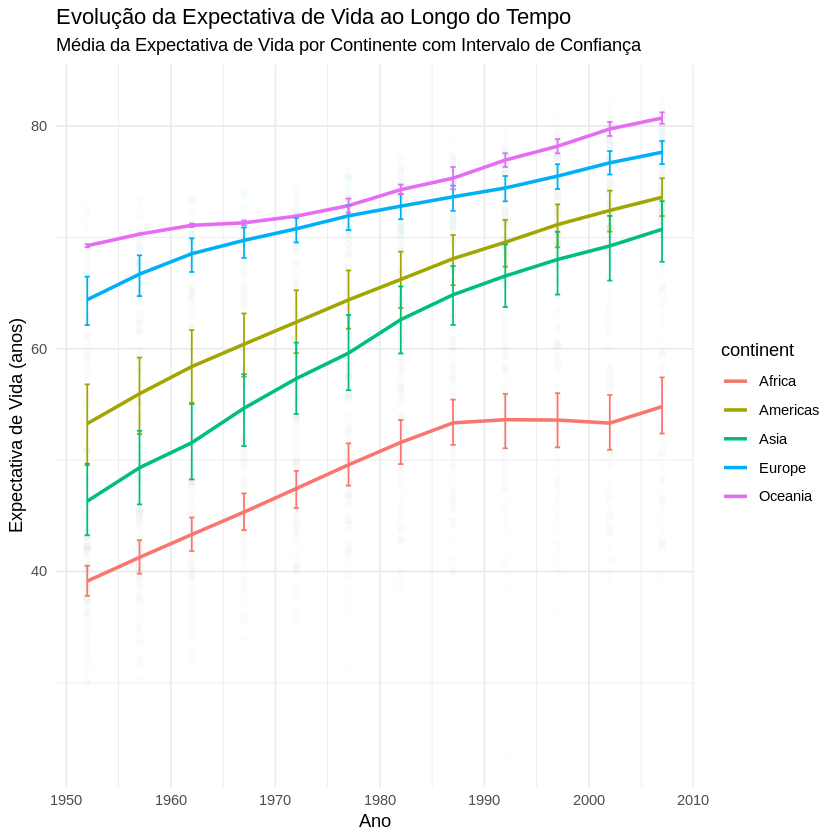

In [112]:
### Instalando o pacote Hmisc para o cálculo de mean_cl_boot: média com intervalo de confiança
install.packages("Hmisc")

# Importando pacotes
library(ggplot2)
library(gapminder)

# Criando o gráfico
ggplot(gapminder, aes(x = year, y = lifeExp, color = continent)) +  # Representando na estética as coordenadas e o divisor dos dados
  geom_point(alpha = 0.01) +  # Adiciona os pontos de dados com alta transparência
  stat_summary(fun = mean, geom = "line", size = 1) +  # Linha da média por continente
  stat_summary(fun.data = mean_cl_boot, geom = "errorbar", width = 0.5) +  # Barras de erro com intervalo de confiança
  labs(title = "Evolução da Expectativa de Vida ao Longo do Tempo",
       subtitle = "Média da Expectativa de Vida por Continente com Intervalo de Confiança",
       x = "Ano",
       y = "Expectativa de Vida (anos)") +
  theme_minimal()

O código adiciona os pontos de dados ao gráfico, representando a expectativa de vida de cada país em cada ano, com uma transparência de 1% para evitar sobreposição excessiva. Para solucionar a nossa questão, utilizamos o stat_summary() duas vezes: o primeiro para adicionar uma linha representando a média da expectativa de vida ao longo do tempo para cada continente e o segundo para adicionar as barras de erro que mostram o intervalo de confiança da média da expectativa de vida para cada continente em cada ano. Ainda adicionamos títulos e rótulos para os eixos, ajudando a contextualizar o gráfico junto a um tema minimalista para um visual mais limpo.


Observando o gráfico gerado, notamos uma evolução da expectativa de vida ao longo dos anos nos continentes, mas com tendências distintas. Além disso, as barras de erros representam a variabilidade dos dados de cada continente de 5 em 5 anos.

Este exemplo, consegue demonstrar o potencial do stat_summary() em resumir de maneira sucinta os dados, apresentando as tendências dos continentes da base gapminder, ajudando a contar uma história baseada em evidências.

# Explorando dados de vendas

**Comparando dados e ajustando eixos**

Qual foi o faturamento por categoria em 2023?

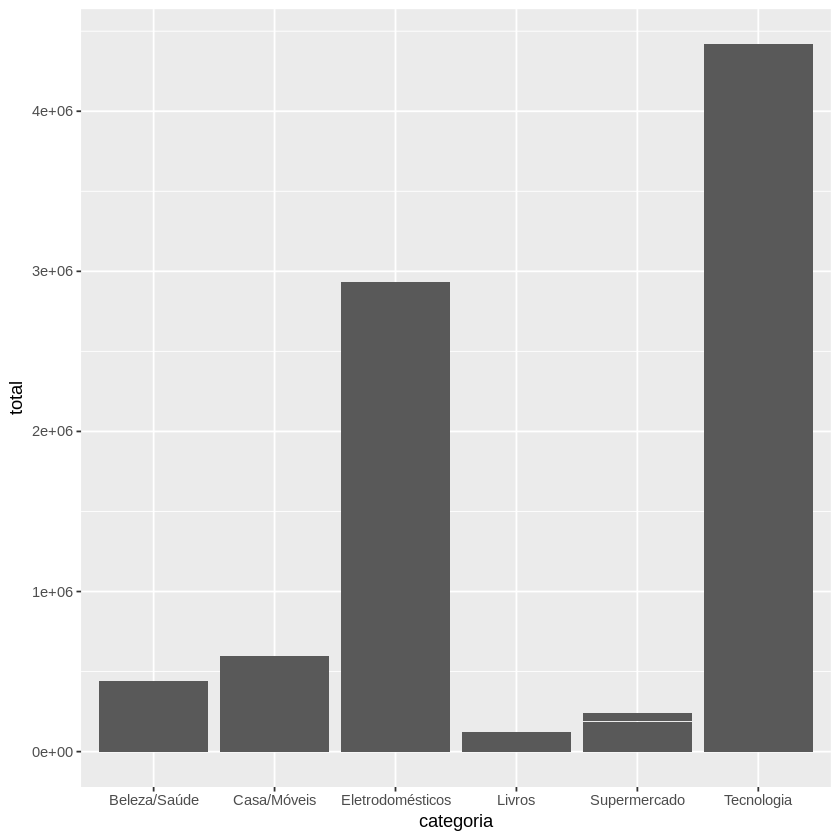

In [113]:
g <- ggplot(
  vendas, aes(x = categoria, y = total)
) +
  geom_col()

g

Ordenando para facilitar visualização

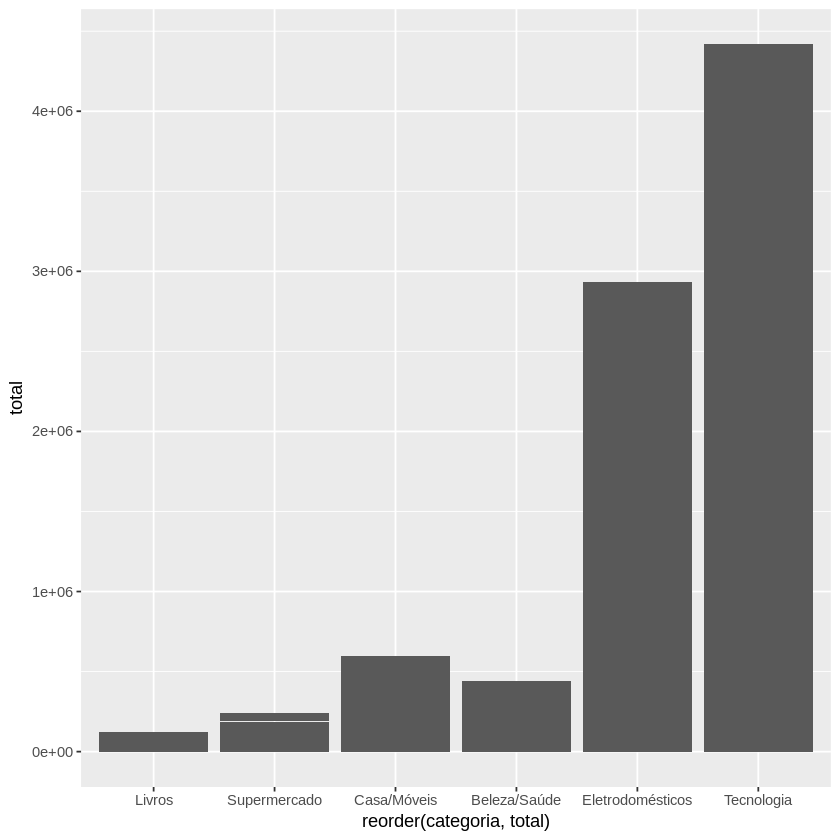

In [114]:
g <- ggplot(
  vendas, aes(x = reorder(categoria, total), y = total)
) +
  geom_col()

g

O reorder ordena pela mediana, então pode dar alguma divergência conforme acima

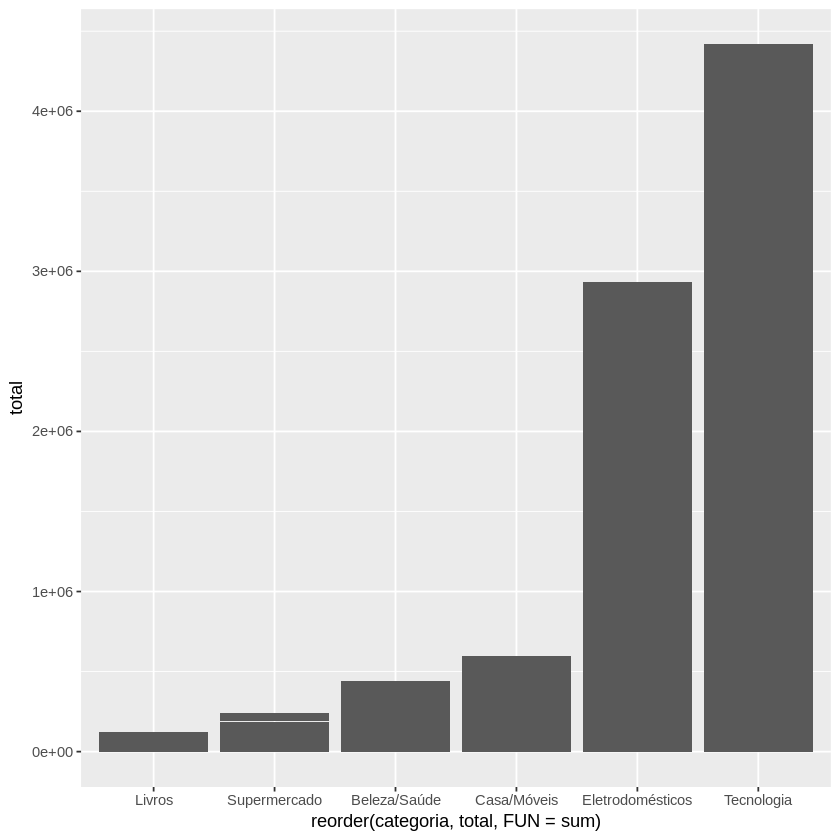

In [115]:
g <- ggplot(
  vendas, aes(x = reorder(categoria, total, FUN=sum), y = total)
) +
  geom_col()

g

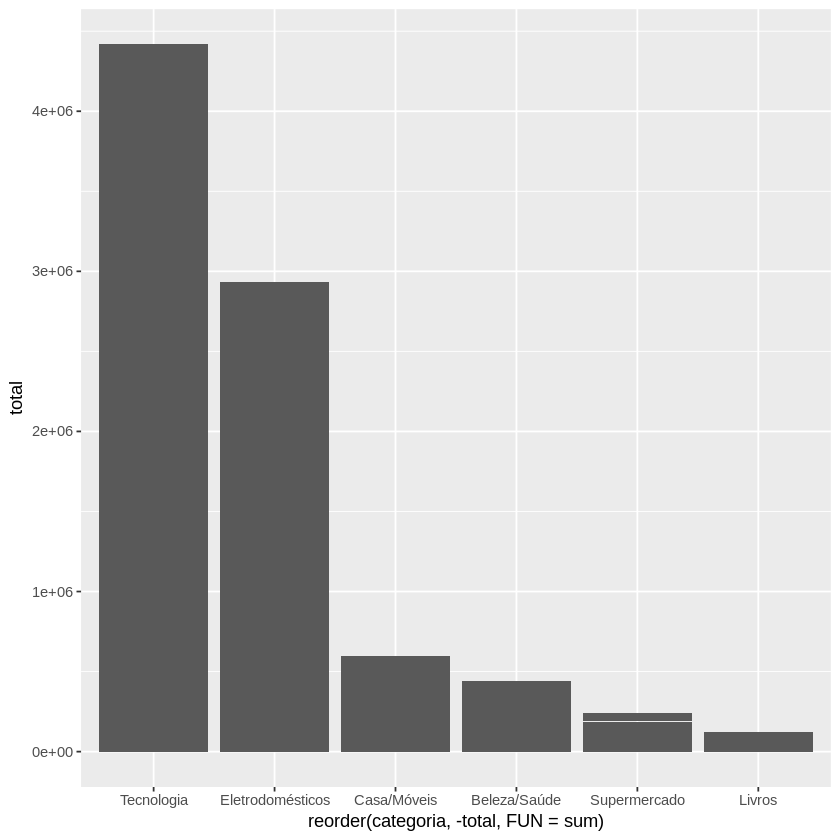

In [116]:
g <- ggplot(
  vendas, aes(x = reorder(categoria, -total, FUN=sum), y = total)
) +
  geom_col()

g

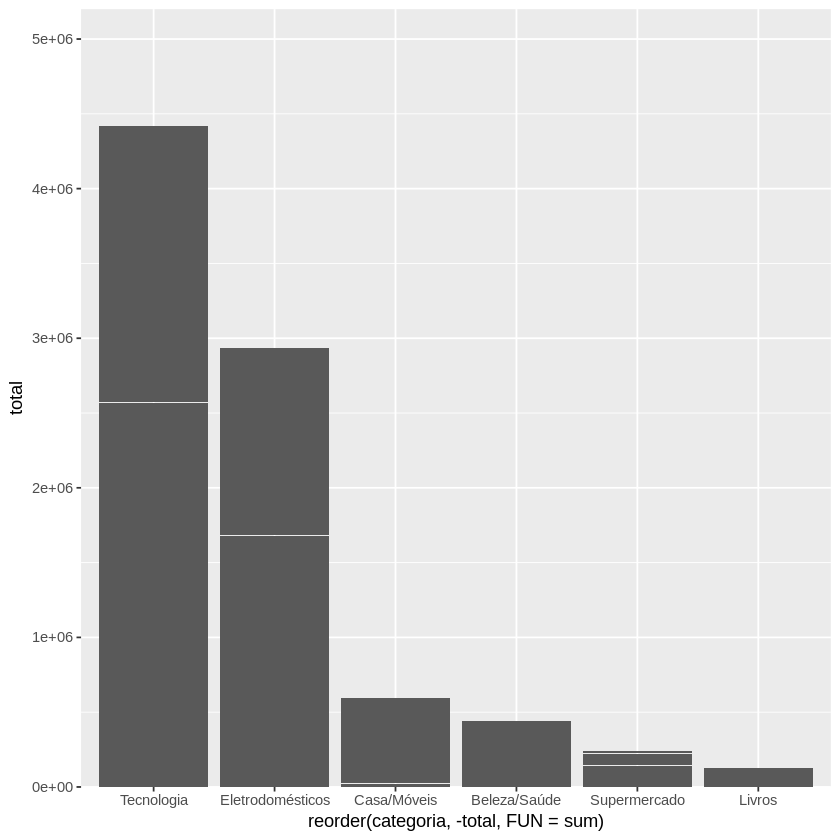

In [117]:
g <- g + scale_y_continuous(expand = c(0,0), limits = c(0,5.2e6))

g

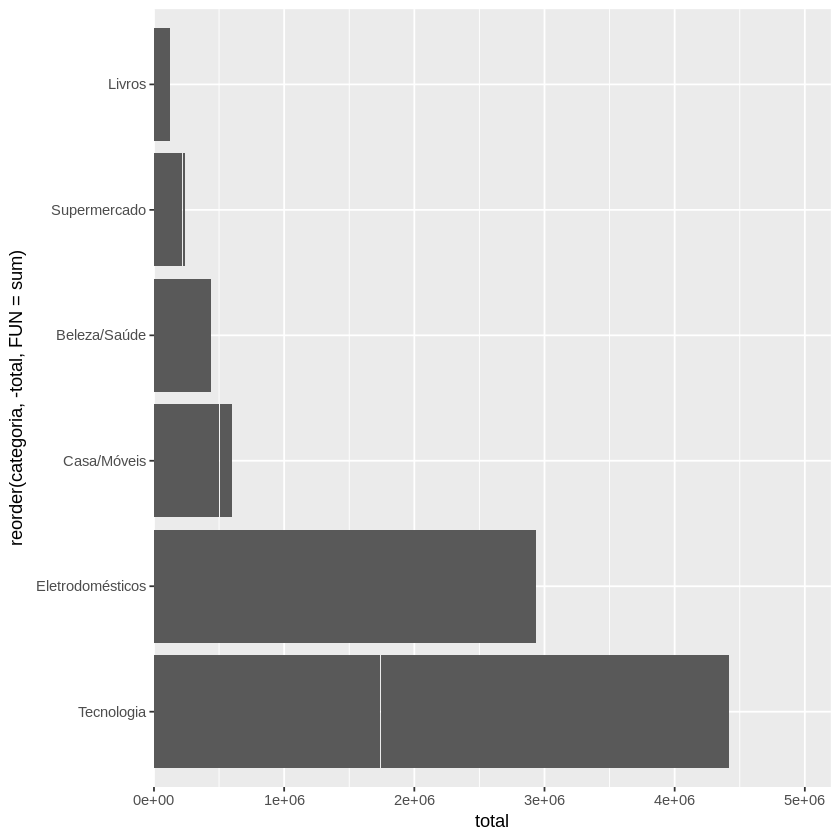

In [118]:
g <- g + coord_flip()

g

**Representando dados temporais**

Qual foi o desempenho das vendas ao longo dos meses em 2023

In [119]:
vendas <- vendas %>%
  mutate(mes = format(data, "%m"))

vendas

ID_compra,data,horario,categoria,preco_unitario,quantidade,frete,metodo_pagamento,total,mes
<dbl>,<date>,<time>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<chr>
6,2023-01-03,20:40:00,Tecnologia,899.19,4,713.26,Boleto,4310.02,01
5,2023-01-03,21:48:00,Casa/Móveis,115.90,1,0.00,PIX,115.90,01
9,2023-01-03,17:08:00,Beleza/Saúde,68.90,2,13.78,Crédito,151.58,01
4,2023-01-03,14:29:00,Casa/Móveis,80.90,5,40.45,PIX,444.95,01
8,2023-01-03,18:02:00,Beleza/Saúde,165.00,4,0.00,PIX,660.00,01
2,2023-01-03,18:42:00,Tecnologia,2028.48,5,1724.37,PIX,11866.77,01
3,2023-01-03,23:47:00,Supermercado,84.90,5,0.00,Crédito,424.50,01
1,2023-01-03,00:13:00,Eletrodomésticos,2169.98,1,138.64,PIX,2308.62,01
7,2023-01-03,17:40:00,Livros,75.90,5,18.98,Crédito,398.48,01


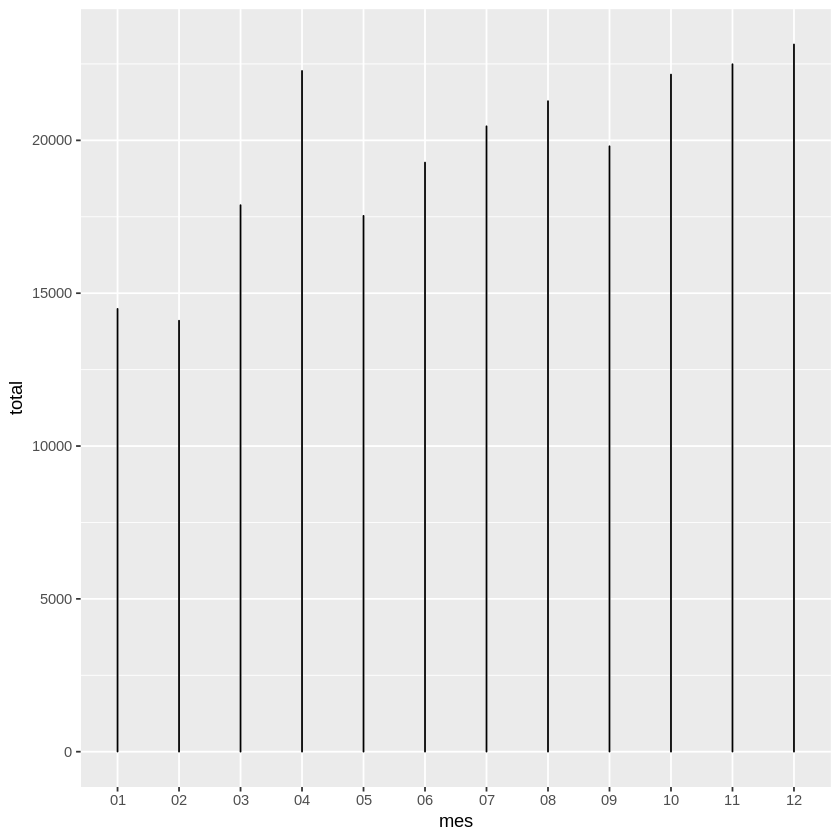

In [120]:
ggplot(vendas, aes(x = mes, y = total)) +
  geom_line()

Agrupando os dados mes a mes para exibir corretamente o gráfico

In [121]:
vendas_por_mes <- vendas %>%
  group_by(mes) %>%
  summarize(vendas_por_mes = sum(total))

vendas_por_mes

mes,vendas_por_mes
<chr>,<dbl>
01,303680.9
02,231224.3
03,281818.2
04,286374.0
05,841253.6
06,781480.5
07,427311.2
08,1006684.6
09,419897.6


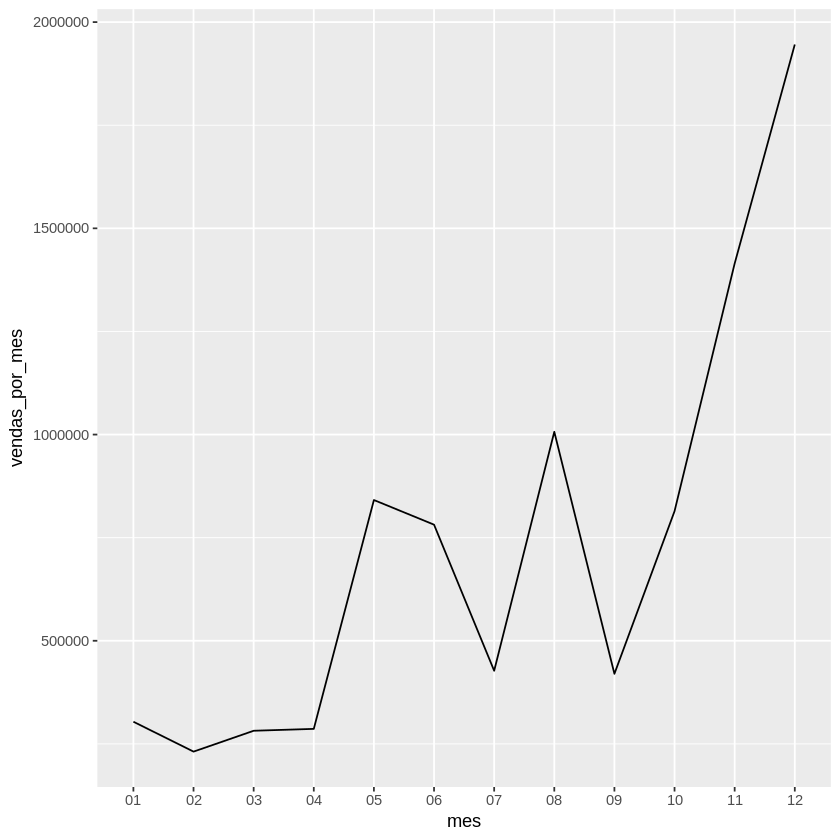

In [122]:
ggplot(vendas_por_mes, aes(x = mes, y = vendas_por_mes, group = 1)) +
  geom_line()

Após corrigir o gráfio de linhas, vamos ajustar o limite, pois acima podemos entender que houve mês com venda negativa

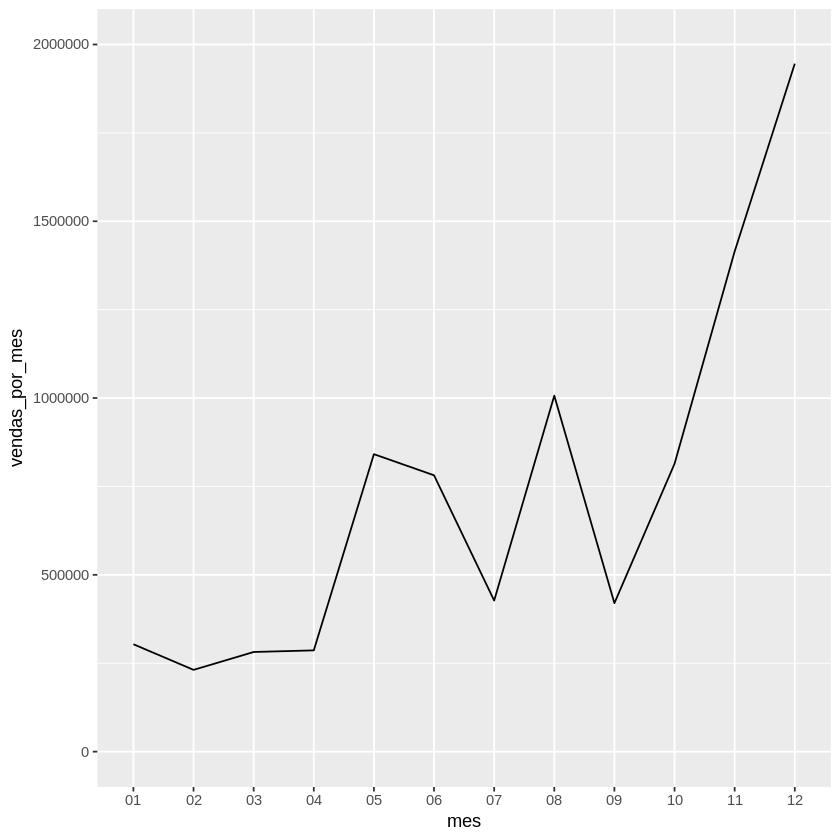

In [123]:
ggplot(vendas_por_mes, aes(x = mes, y = vendas_por_mes, group = 1)) +
  geom_line() +
  ylim(c(0,2e6))

Melhorando o gráfico

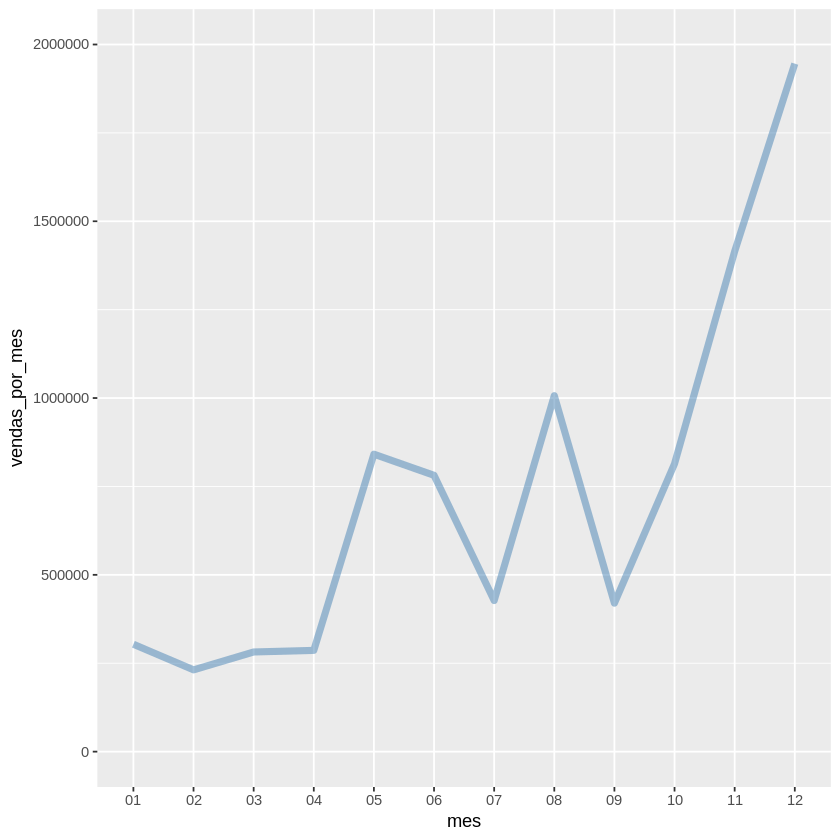

In [124]:
ggplot(vendas_por_mes, aes(x = mes, y = vendas_por_mes, group = 1)) +
  geom_line(linewidth = 2, color = "steelblue", alpha = 0.5) +
  ylim(c(0,2e6))

**Para saber mais: funções de formatação de eixos**

Ao criar visualizações em R com o pacote ggplot2, o controle sobre os eixos e a exibição dos dados é essencial para construir gráficos customizados e claros. Existem duas funções que desempenham papeis semelhantes nesse aspecto, mas com algumas diferenças interessantes entre elas: coord_cartesian() e scale_*_continuous(). Ambas permitem ajustar a forma como os eixos são apresentados, mas cada uma delas possui características e funcionalidades distintas. Agora, vamos explorar cada uma delas.

**coord_cartesian()**

A função coord_cartesian() é utilizada para ajustar os limites visuais dos eixos em um gráfico, sem alterar os dados subjacentes. Ou seja, ela realiza o "zoom" ou corte nos eixos do gráfico sem modificar ou excluir dados, apenas restringindo a área visível.

**Em resumo, ela serve basicamente para:**

* Focar em uma área específica do gráfico.

* Não excluir dados fora do intervalo definido, apenas ajustar a área visível.

* Manter o cálculo de estatísticas com base em todo o conjunto de dados.

Vamos ver um exemplo de seu uso? Utilizaremos a base starwars, que contém informações sobre personagens da saga Star Wars. Estamos interessados em visualizar a relação entre altura (height) e massa (mass) dos personagens, mas queremos focar em uma faixa específica dos dados (entre 100 a 200 cm e 0 a 150 kg). O código para gerar um gráfico de dispersão com esses dados é o seguinte:

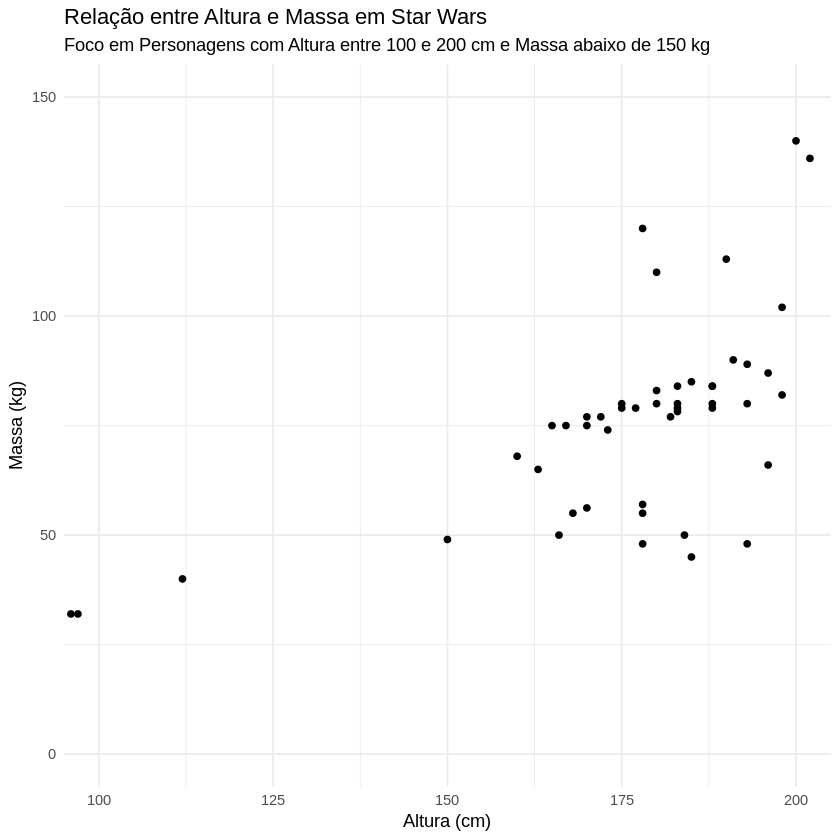

In [125]:
library(ggplot2)
library(dplyr)

# Filtrando a base starwars para remover NA
starwars_clean <- starwars %>%
  filter(!is.na(height), !is.na(mass))

# Gráfico com coord_cartesian() para focar em um intervalo específico
ggplot(starwars_clean, aes(x = height, y = mass)) +
  geom_point() +
  coord_cartesian(xlim = c(100, 200), ylim = c(0, 150)) +
  labs(
    title = "Relação entre Altura e Massa em Star Wars",
    subtitle = "Foco em Personagens com Altura entre 100 e 200 cm e Massa abaixo de 150 kg",
    x = "Altura (cm)",
    y = "Massa (kg)"
  ) +
  theme_minimal()

**scale_*_continuous()**

A função scale_*_continuous() (onde * pode ser x ou y) também é utilizada para ajustar os eixos, mas sua ação é mais ativa: ela modifica o próprio mapeamento dos dados no gráfico. Isso significa que, ao definir limites com scale_*_continuous(), os dados fora do intervalo são completamente removidos do gráfico.

Em resumo, ela serve basicamente para:

Definir os limites dos eixos e remover os pontos fora desses limites.
Alterar o cálculo de estatísticas de acordo com o intervalo desejado, já que exclui os dados fora dos limites.
Filtrar os dados diretamente no gráfico.
Vamos ver um exemplo de seu uso? Agora, vamos usar scale_x_continuous() e scale_y_continuous() para mostrar somente os personagens cujas alturas estão entre 100 e 200 cm, e cujas massas estão abaixo de 150 kg. Observe que os pontos fora desses limites serão excluídos do gráfico.

Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


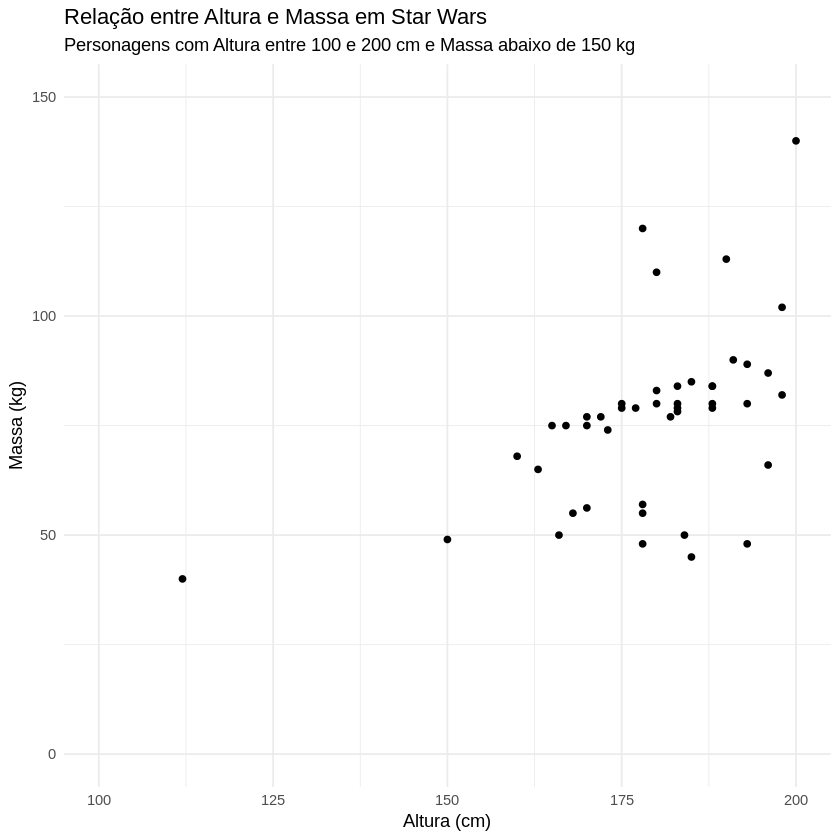

In [126]:
# Gráfico com scale_*_continuous() que remove dados fora dos limites
ggplot(starwars_clean, aes(x = height, y = mass)) +
  geom_point() +
  scale_x_continuous(limits = c(100, 200)) +
  scale_y_continuous(limits = c(0, 150)) +
  labs(
    title = "Relação entre Altura e Massa em Star Wars",
    subtitle = "Personagens com Altura entre 100 e 200 cm e Massa abaixo de 150 kg",
    x = "Altura (cm)",
    y = "Massa (kg)"
  ) +
  theme_minimal()

Testando o código acima, poderá observar que os gráficos são semelhantes, mas receberá um warning no Console do R dizendo o seguinte:

Warning message:
Removed 14 rows containing missing values or values outside the scale range (`geom_point()`).

Ou seja, filtramos os nossos dados eliminando os 14 registros na criação do visual. A depender do que o usuário precise em seu projeto, essa remoção pode ser algo desejado ou impactar negativamente em seus resultados.




---

O uso das funções coord_cartesian() e scale_*_continuous() devem ser pensadas de acordo com o objetivo da análise e o que ele deseja apresentar ao seu público. Resumindo, o coord_cartesian() é ideal quando você deseja focar em uma parte específica do gráfico sem perder os dados subjacentes, enquanto scale_*_continuous() é preferível quando você deseja excluir dados fora de uma faixa de interesse, alterando a forma como os dados são representados visualmente e estatisticamente. A escolha entre elas depende do contexto e da intenção da visualização de dados.



**Combinando visuais**

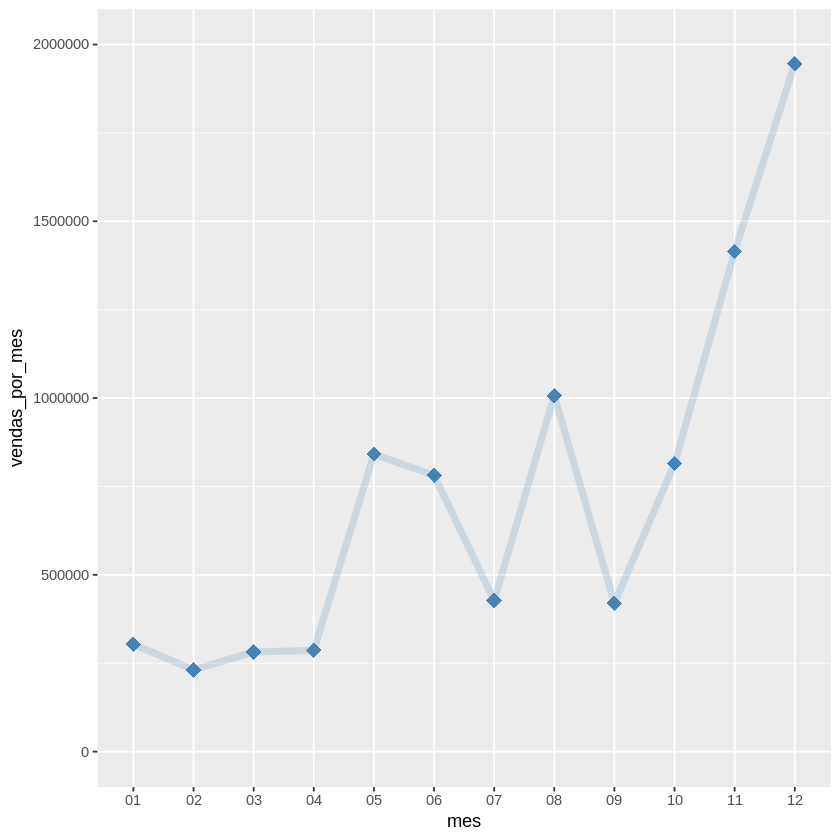

In [127]:
ggplot(vendas_por_mes, aes(x = mes, y = vendas_por_mes, group=1)) +
  geom_line(linewidth = 2, color = "steelblue", alpha = 0.2) +
  geom_point(size = 4, color = "steelblue", shape = "diamond") +
  ylim(0,2e6)

**Agrupando e empilhando dados**

In [128]:
vendas <- vendas %>%
  mutate(trimestre = as.factor(quarter(data)))

head(vendas)

ID_compra,data,horario,categoria,preco_unitario,quantidade,frete,metodo_pagamento,total,mes,trimestre
<dbl>,<date>,<time>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<chr>,<fct>
6,2023-01-03,20:40:00,Tecnologia,899.19,4,713.26,Boleto,4310.02,01,1
5,2023-01-03,21:48:00,Casa/Móveis,115.90,1,0.00,PIX,115.90,01,1
9,2023-01-03,17:08:00,Beleza/Saúde,68.90,2,13.78,Crédito,151.58,01,1
4,2023-01-03,14:29:00,Casa/Móveis,80.90,5,40.45,PIX,444.95,01,1
8,2023-01-03,18:02:00,Beleza/Saúde,165.00,4,0.00,PIX,660.00,01,1
2,2023-01-03,18:42:00,Tecnologia,2028.48,5,1724.37,PIX,11866.77,01,1


In [129]:
vendas_por_tri <- vendas %>%
  group_by(trimestre, metodo_pagamento) %>%
  summarize(total_tri = sum(total))

vendas_por_tri

`summarise()` has grouped output by 'trimestre'. You can override using the
`.groups` argument.


trimestre,metodo_pagamento,total_tri
<fct>,<fct>,<dbl>
1,Boleto,176995.3
1,Crédito,287167.0
1,PIX,352561.2
2,Boleto,344944.0
2,Crédito,874828.0
2,PIX,689336.1
3,Boleto,245148.3
3,Crédito,941987.8
3,PIX,666757.3


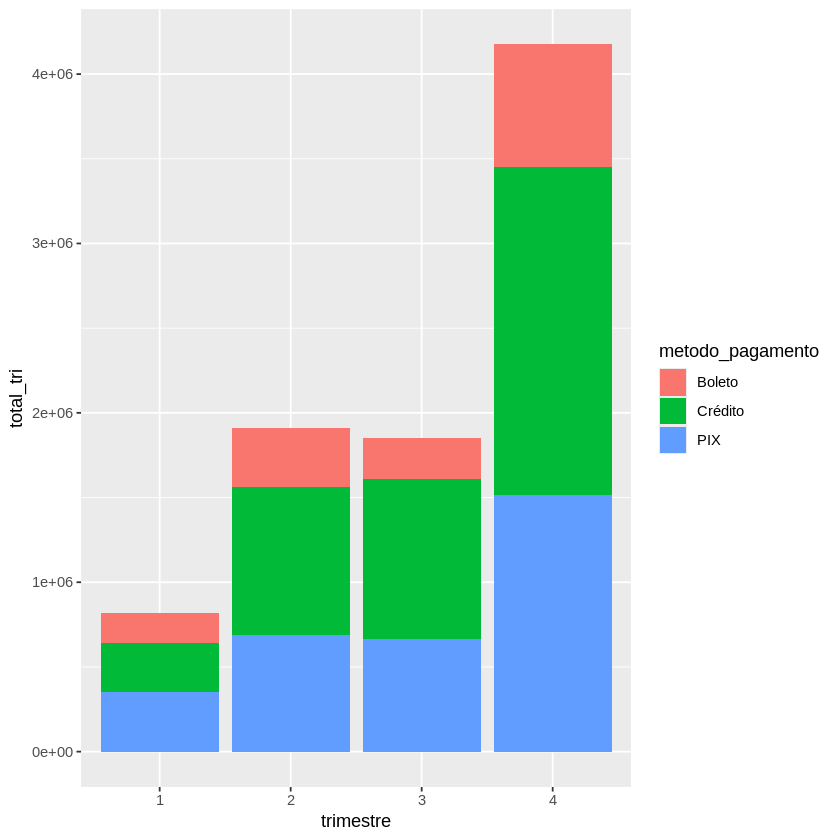

In [130]:
ggplot(vendas_por_tri, aes(x = trimestre, y = total_tri, fill = metodo_pagamento)) +
  geom_col()

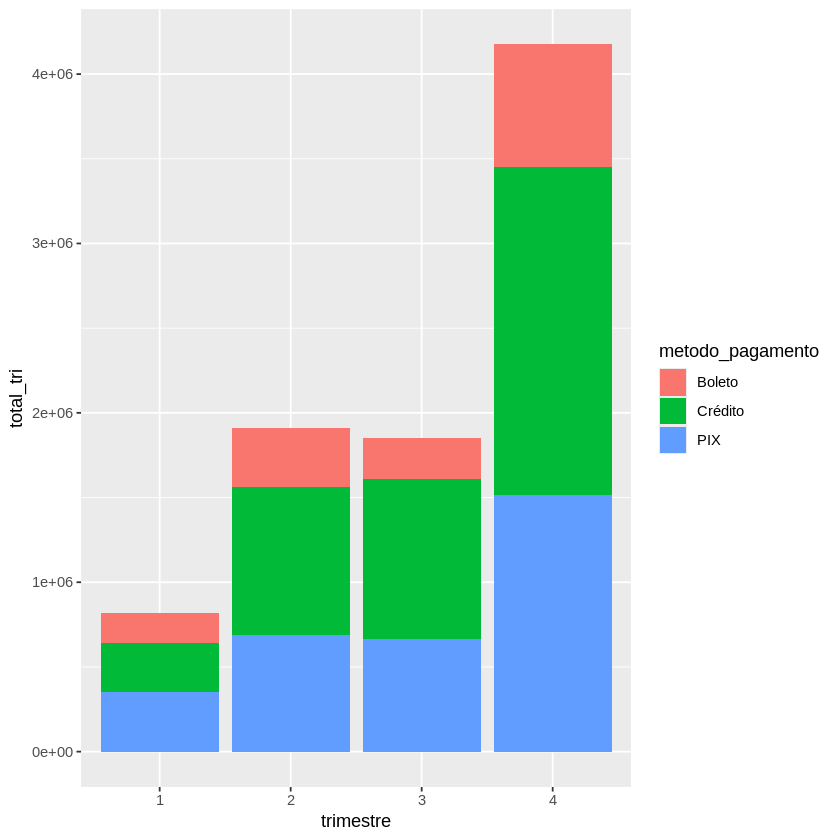

In [131]:
ggplot(vendas_por_tri, aes(x = trimestre, y = total_tri, fill = metodo_pagamento)) +
  geom_col(position = "stack")

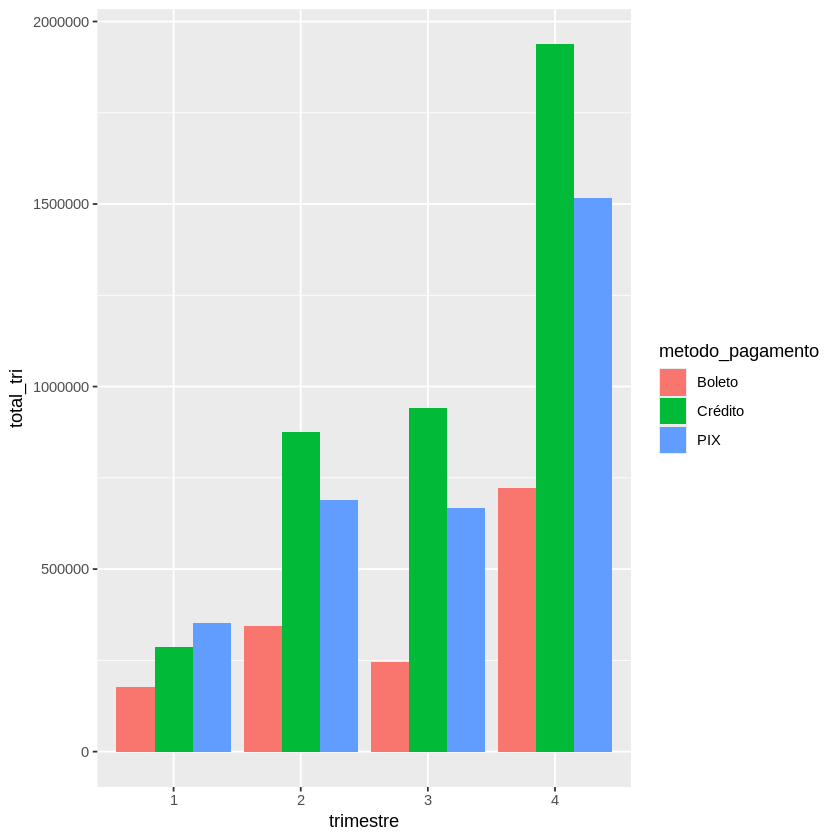

In [132]:
ggplot(vendas_por_tri, aes(x = trimestre, y = total_tri, fill = metodo_pagamento)) +
  geom_col(position = "dodge")

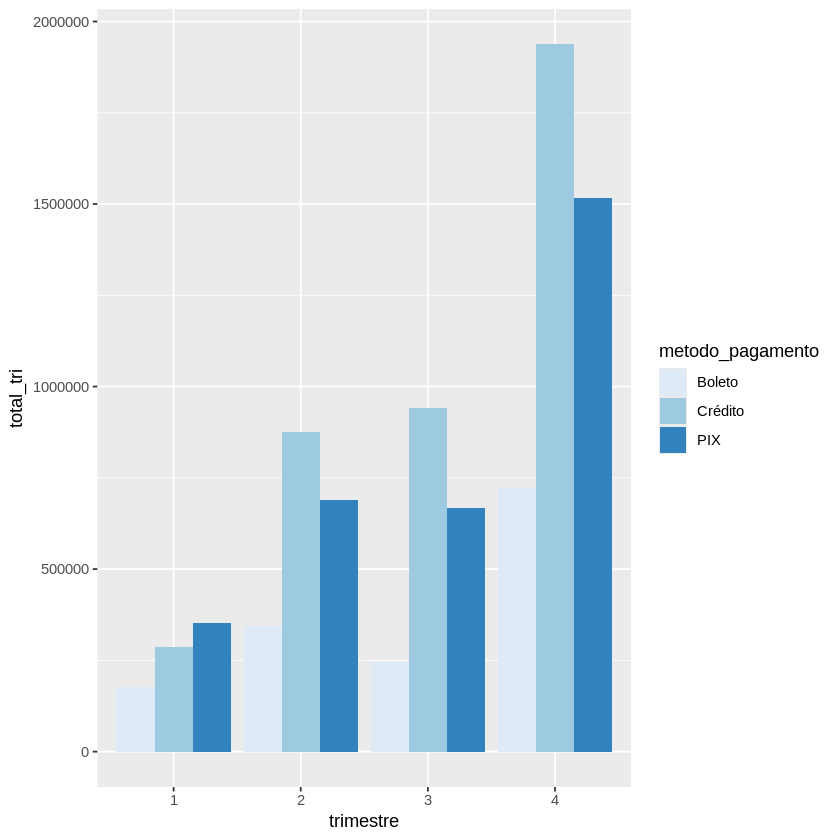

In [133]:
ggplot(vendas_por_tri, aes(trimestre, total_tri, fill = metodo_pagamento)) +
  geom_col(position = "dodge") +
  scale_fill_brewer(palette = "Blues")

In [134]:
cores <- c("lightskyblue1","steelblue","dodgerblue4")

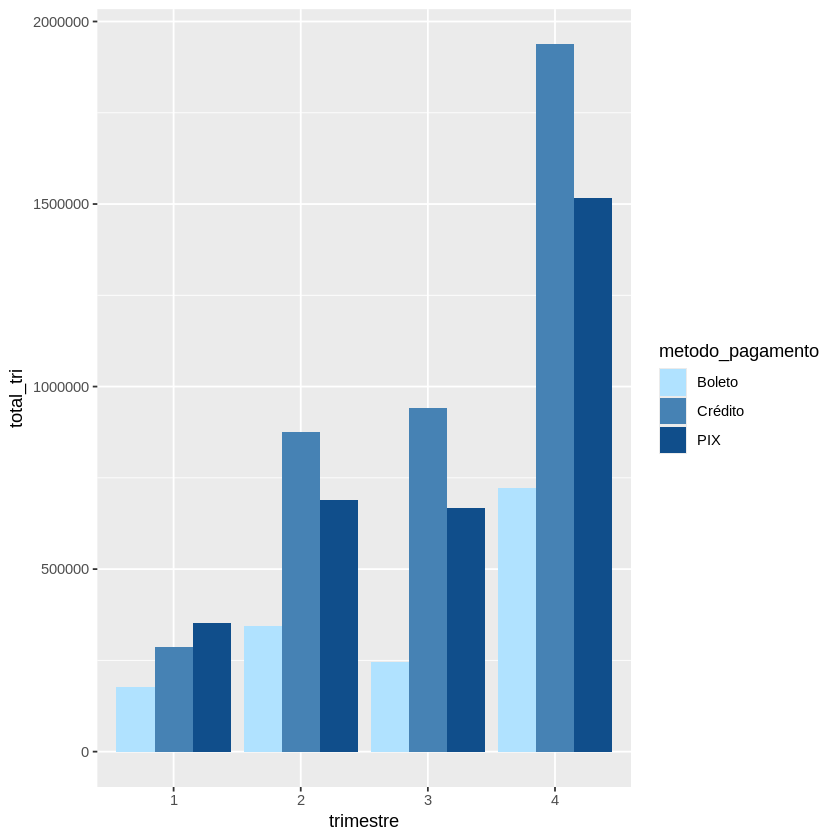

In [135]:
ggplot(vendas_por_tri, aes(trimestre, total_tri, fill = metodo_pagamento)) +
  geom_col(position = "dodge") +
  scale_fill_manual(values = cores)

**Para saber mais: criando painéis com visuais**

Uma funcionalidade bem interessante em gráficos no ggplot2 é a criação relativamente simples de múltiplos paineis baseados em variáveis categóricas. No ggplot2, essa funcionalidade é implementada pela camada facet, utilizando as funções facet_wrap() ou facet_grid(). Elas permitem criar múltiplos gráficos lado a lado, organizados por uma ou mais variáveis, facilitando a comparação entre diferentes subconjuntos de dados.


**A camada Facet no ggplot2**


A partir dessa camada você consegue dividir o espaço do gráfico em sub gráficos, cada um mostrando uma fatia dos dados. É bastante útil quando queremos comparar padrões ou tendências entre diferentes categorias de uma variável.

**facet_wrap()**

A função facet_wrap() organiza os gráficos em uma série de "subplots" de uma única dimensão, permitindo que os dados sejam segmentados com base em uma variável categórica.

Em resumo, ela serve basicamente para:

Quando queremos visualizar gráficos para categorias de uma única variável.
Dividir os gráficos em múltiplos paineis, permitindo comparações diretas entre os subconjuntos dos dados.
Dispor gráficos de maneira flexível, ajustando-se ao tamanho da janela do gráfico.
Para exemplificar, vamos criar um gráfico de dispersão com a base gapminder mostrando a relação entre a expectativa de vida (lifeExp) e o PIB per capita (gdpPercap) . Além disso, usar facet_wrap() para dividir os gráficos por continente.

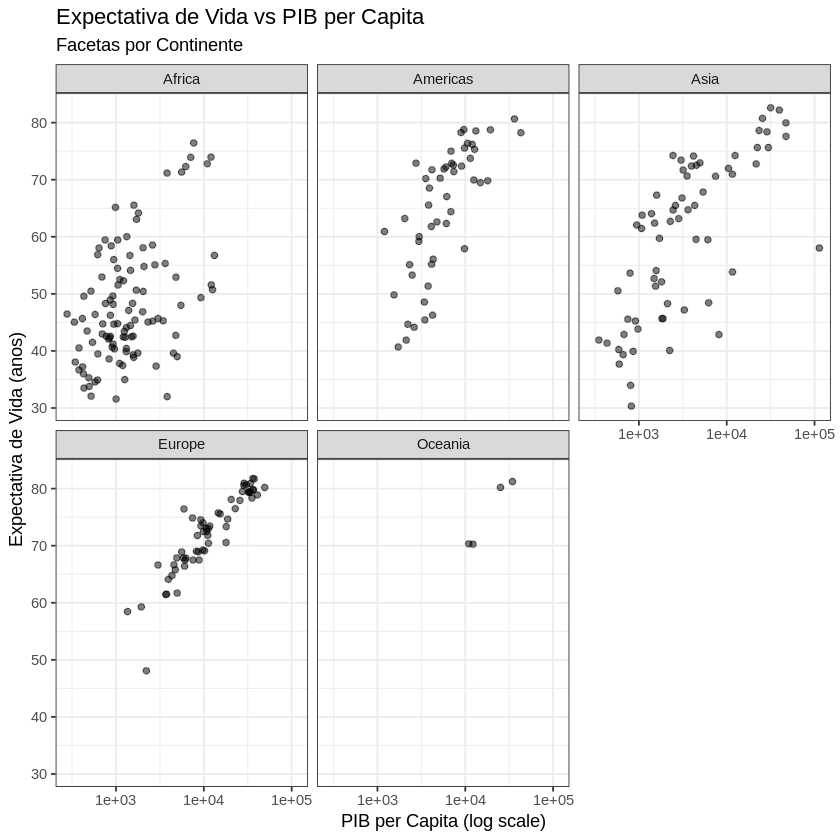

In [136]:
library(ggplot2)
library(dplyr)
library(gapminder)

# Carregando a base de dados gapminder para 1957 e 2007
gapminder_1957_2007<- gapminder %>%
  filter(year %in% c(1957, 2007))

# Gráfico com facet_wrap()
ggplot(gapminder_1957_2007 , aes(x = gdpPercap, y = lifeExp)) +
  geom_point(alpha = 0.5) +
  scale_x_log10() +  # Escala logarítmica para o eixo x
  labs(
    title = "Expectativa de Vida vs PIB per Capita",
    subtitle = "Facetas por Continente",
    x = "PIB per Capita (log scale)",
    y = "Expectativa de Vida (anos)"
  ) +
  facet_wrap(~continent) +
  theme_bw()

No visual acima, facet_wrap(~continent) divide os gráficos por continente, permitindo comparar como a relação entre PIB per capita (em log) e expectativa de vida varia em diferentes partes do mundo. O gráfico é organizado automaticamente em uma grade.


**facet_grid()**

A função facet_grid() cria uma grade fixa de gráficos baseados em duas variáveis, uma organizando os gráficos nas colunas e outra nas linhas. É útil quando você quer visualizar dados ao longo de duas dimensões categóricas e deseja manter uma organização rígida.

Em resumo, ela serve basicamente para:

Dividir os gráficos em uma grade com base em duas variáveis categóricas.
Assegurar que todas as combinações de gráficos sejam exibidas, mesmo que não haja dados em certas combinações.
Manter uma disposição consistente de linhas e colunas.
Agora, vamos usar facet_grid() para criar gráficos que mostram a relação entre PIB per capita e expectativa de vida, dividindo os múltiplos gráficos por continente e ano.

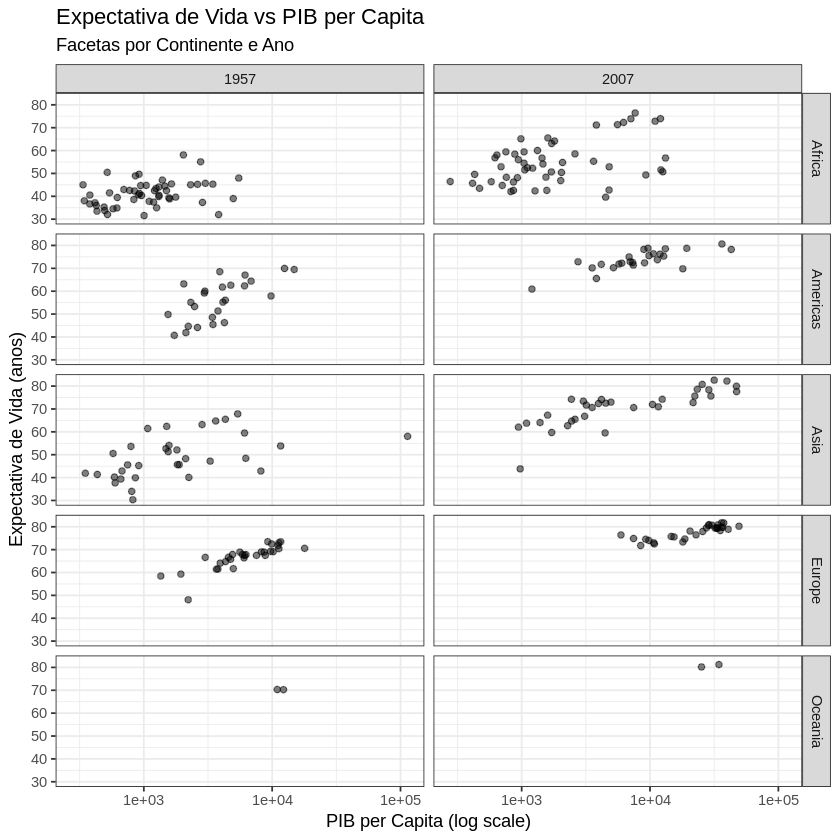

In [137]:
# Gráfico com facet_grid()
ggplot(gapminder_1957_2007 , aes(x = gdpPercap, y = lifeExp)) +
  geom_point(alpha = 0.5) +
  scale_x_log10() +  # Escala logarítmica para o eixo x
  labs(
    title = "Expectativa de Vida vs PIB per Capita",
    subtitle = "Facetas por Continente e Ano",
    x = "PIB per Capita (log scale)",
    y = "Expectativa de Vida (anos)"
  ) +
  facet_grid(continent ~ year) +
  theme_bw()

Aqui, facet_grid(continent ~ year) divide os gráficos tanto por continente (linhas) quanto por ano (colunas). Essa abordagem permite comparar como a relação entre PIB per capita e expectativa de vida evolui ao longo do tempo em diferentes continentes.



---

O uso de facets pode auxiliar bastante na análise dos dados de diferentes grupos e características, permitindo dividir visualizações em subgráficos organizados, facilitando comparações dentro dos dados. Resumindo, facet_wrap() é mais adequado para segmentação com base em uma única variável categórica, já facet_grid() é a escolha ideal quando se quer comparar dados ao longo de duas variáveis.

O uso de cada uma dessas funções depende da estrutura dos dados e das perguntas que a pessoa cientista de dados deseja responder. Ambas as funções ajudam a tornar os dados mais acessíveis e compreensíveis, especialmente em análises de dados multidimensionais.


# Personalizado os visuais

**Definindo o tema dos visuais**

In [138]:
nomes <- c("red_1", "red_2", "red_3", "grey_1", "grey_2",
           "grey_3", "blue_1", "blue_2", "blue_3")
cores <- c("#ee8399", "#e23155", "#881d33", "#f3f3f3", "#ebebeb",
           "#8d8d8d", "#a3adbd", "#5e708c", "#19325b")

for (i in seq(nomes)) assign(nomes[i],cores[i])

In [139]:
grafico_vendas_mes <-
    ggplot(vendas_por_mes, aes(x = mes, y = vendas_por_mes, group=1)) +
        geom_line(linewidth = 2, color = blue_2, alpha = 0.2) +
        geom_point(size = 4, color = blue_2, shape = "diamond") +
        ylim(0,2e6)

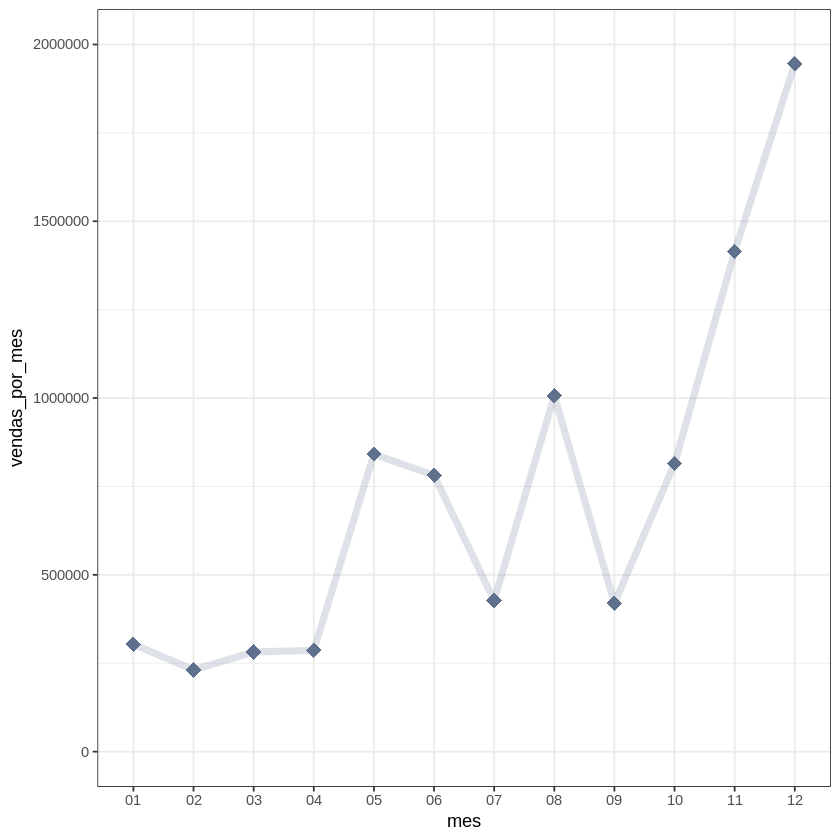

In [140]:
grafico_vendas_mes + theme_bw()

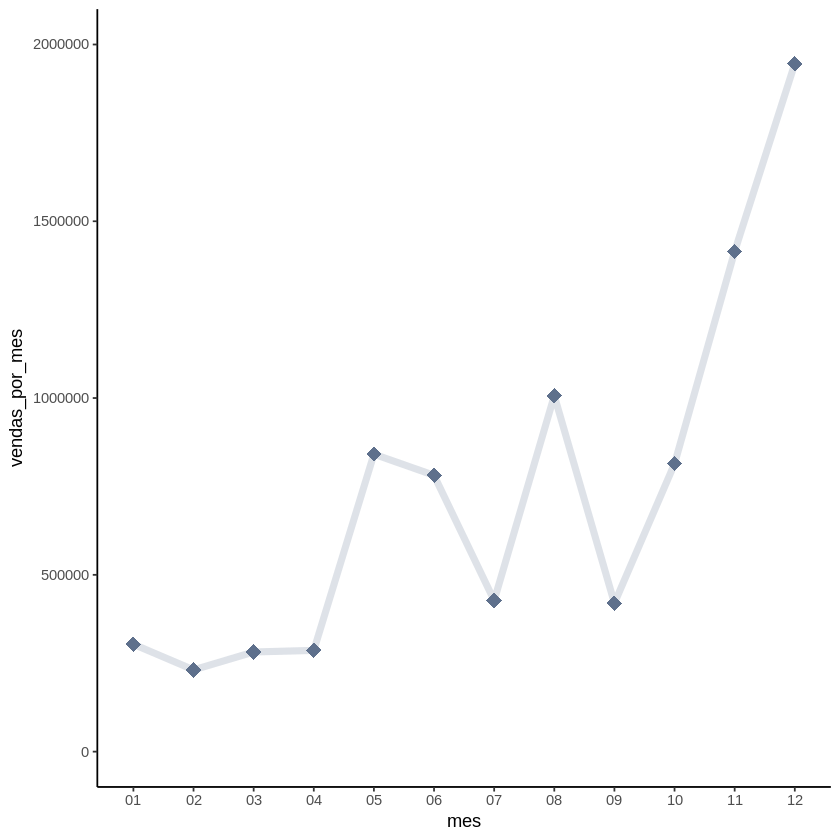

In [141]:
grafico_vendas_mes + theme_classic()

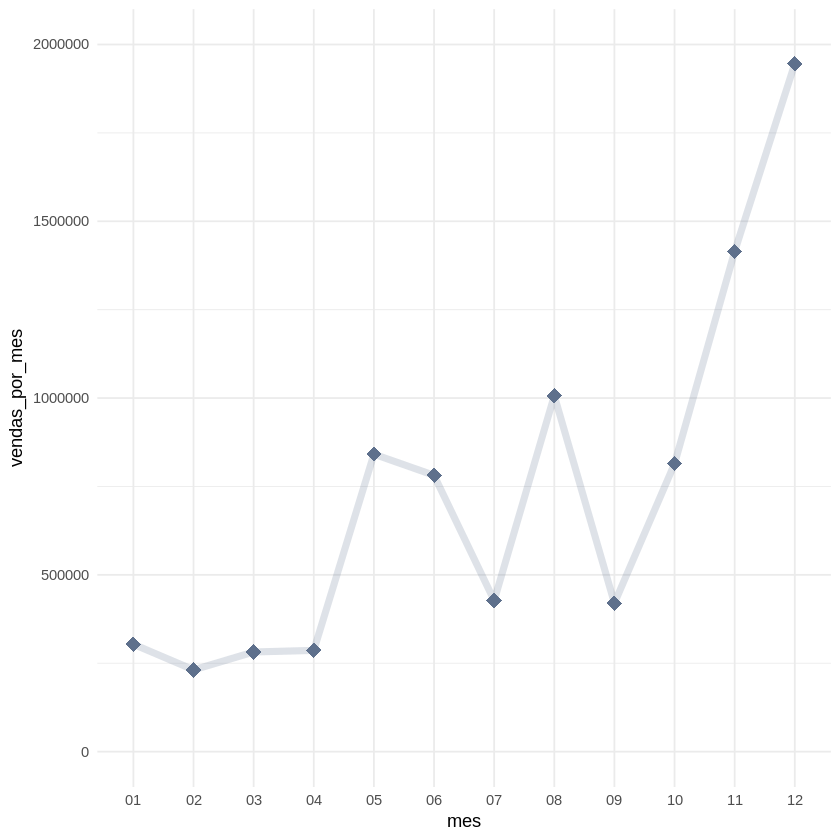

In [142]:
grafico_vendas_mes + theme_minimal()

Criando nosso próprio tema:

In [143]:
tema <- theme_minimal() +
  theme(panel.grid.major.x = element_blank(),
        plot.title = element_text(size=14, face="bold", vjust = +2),
        axis.text = element_text(size = 10),
        axis.title.x = element_text(size = 12, face = "bold", vjust = -1),
        axis.title.y = element_text(size = 12, face = "bold", vjust = +3),
        legend.position = "bottom"
        )

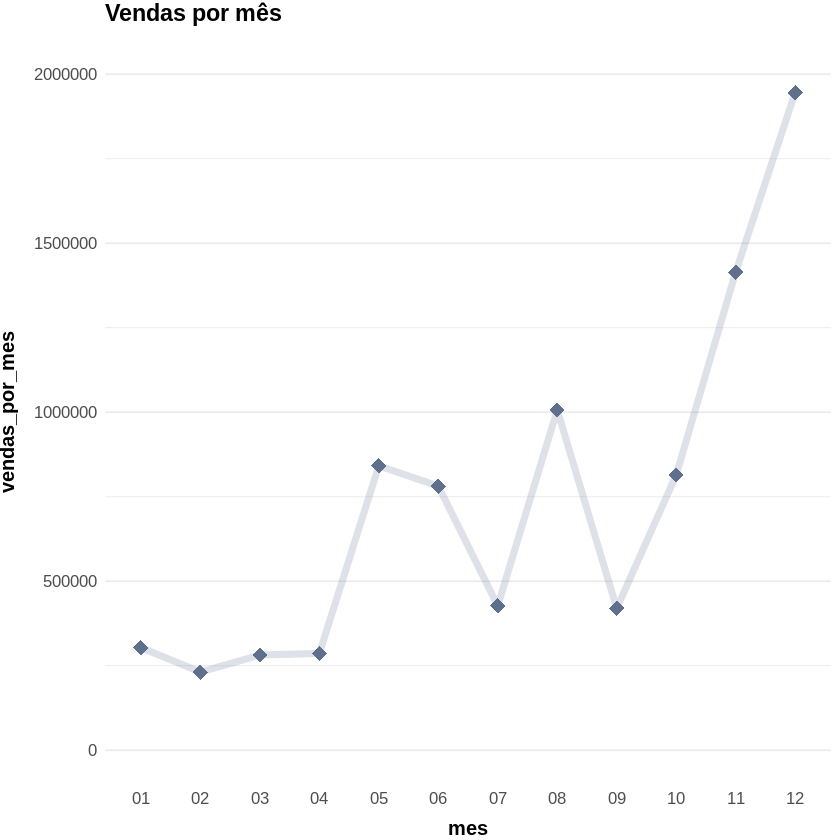

In [144]:
grafico_vendas_mes + tema + labs(title="Vendas por mês")

**Para saber mais: Análise exploratória X Análise explanatória**

Em análises de dados, é comum a utilização de gráficos para comunicar informações de forma visual. No entanto, nem todos os gráficos são criados com o mesmo propósito.

Podemos dividir as visualizações em dois tipos principais: gráficos exploratórios e gráficos explanatórios. Enquanto os gráficos exploratórios são ferramentas utilizadas pela pessoa analista e cientista de dados para investigar padrões e entender os dados, os gráficos explanatórios são desenhados para apresentar conclusões claras ao público, enfatizando insights específicos e comunicando uma narrativa.

**Gráficos Exploratórios**


Os gráficos exploratórios são utilizados durante a análise com a finalidade de explorar os dados, detectar padrões, testar hipóteses e entender melhor a estrutura da base de dados. Esses gráficos servem mais como uma ferramenta de investigação do que de comunicação. Eles são rápidos de criar e permitem uma visão abrangente dos dados, sem necessariamente se preocupar com estética ou clareza para um público externo.

Em resumo, suas principais características são:

Investigação dos dados durante a fase de análise e exploração de dados.
Não possuem um foco estético ou de narrativa.
Servem para revelar padrões ocultos, anomalias ou insights que ainda precisam ser refinados.
Podem ser complexos, pois são projetados para a própria pessoa analista ou cientista.
Vamos observar um exemplo de visual exploratório com a base de dados do gapminder. Criaremos um histograma para observar a distribuição da expectativa de vida em 2002 para todos os países. Esse gráfico ajuda um analista a entender a variação nos dados.

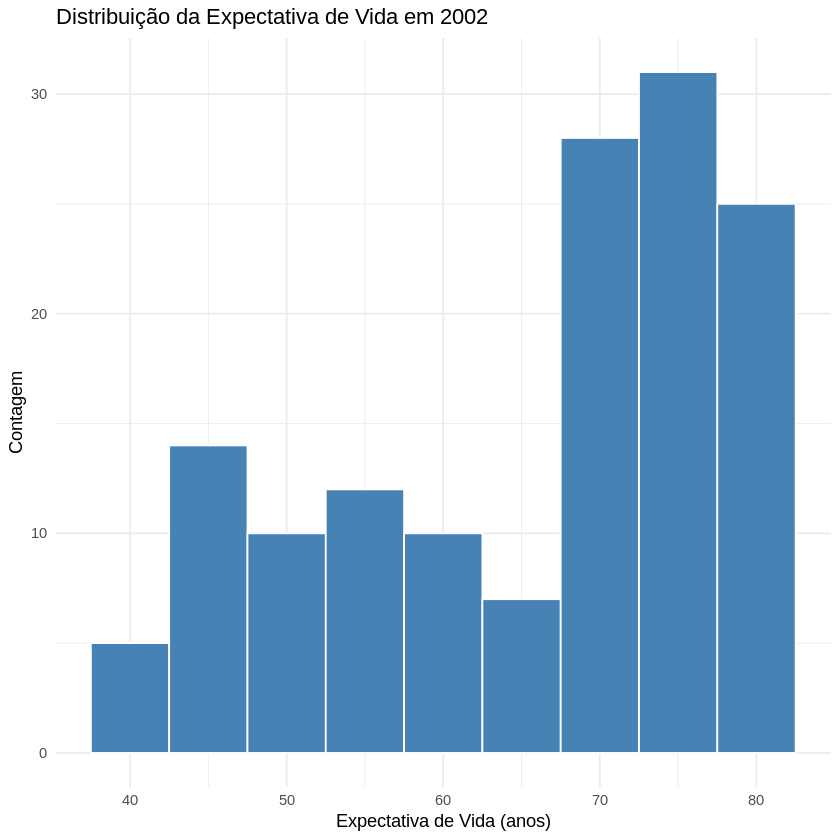

In [145]:
library(ggplot2)
library(dplyr)
library(gapminder)

# Filtrando os dados para o ano de 2002
gapminder_2002 <- gapminder %>%
  filter(year == 2002)

# Criando o histograma exploratório
ggplot(gapminder_2002, aes(x = lifeExp)) +
  geom_histogram(binwidth = 5, fill = "steelblue", color = "white") +
  labs( title = "Distribuição da Expectativa de Vida em 2002",
        x = "Expectativa de Vida (anos)",
        y = "Contagem") +
  theme_minimal()

**Gráficos Explanatórios**


Os gráficos explanatórios são construídos para contar uma história e comunicar claramente um insight ou resultado ao público. Eles são projetados com cuidado para serem esteticamente agradáveis, diretos e fáceis de entender, enfatizando pontos importantes que suportam a conclusão da pessoa analista e cientista. O design e a apresentação visual são fundamentais para destacar o que deseja apresentar.

Em resumo, suas principais características são:

Comunicar um insight específico ao público.
Serem claros, focados e estilizados para aumentar a compreensão.
Simplificar os dados, focando em pontos importantes.
Incluir elementos como rótulos, legendas e destaques para reforçar a narrativa.
Agora, vamos criar um gráfico explanatório (lollipop chart) para mostrar as 5 maiores e 5 menores expectativas de vida em 2002. Nesse gráfico, vamos incluir também a média global para fornecer contexto ao nosso visual.

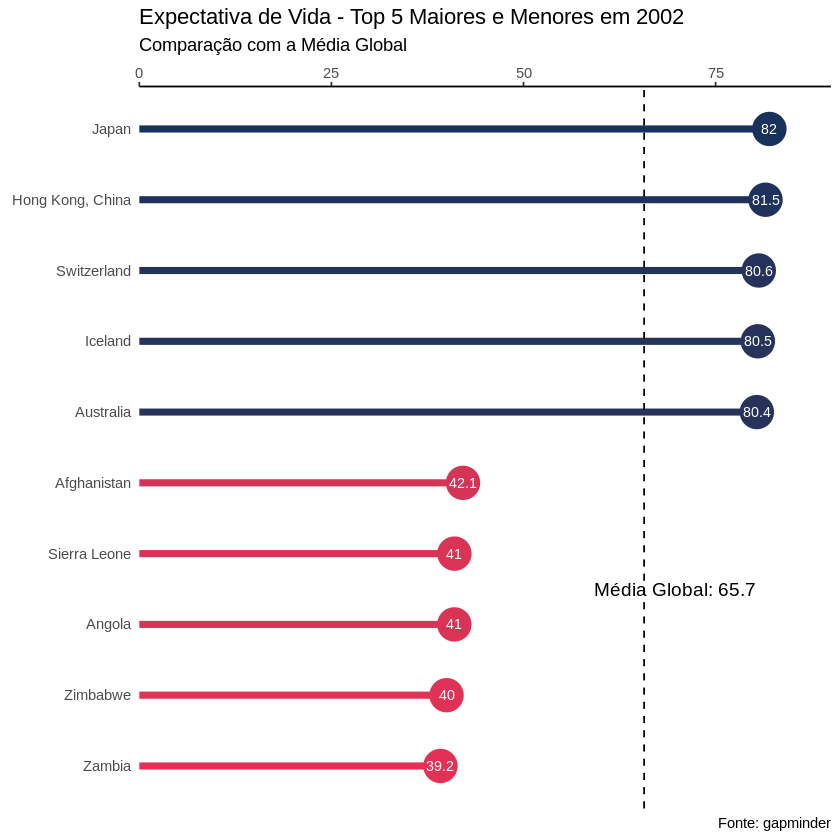

In [146]:
# Calculando a média global de expectativa de vida em 2002
media_global_2002 <- mean(gapminder_2002$lifeExp)

# Selecionando os Top 5 maiores e menores valores de expectativa de vida
gm_max_2002 <- gapminder_2002 %>%
  arrange(desc(lifeExp)) %>%
  slice_max(lifeExp, n=5)

gm_min_2002 <- gapminder_2002 %>%
  arrange(lifeExp) %>%
  slice_min(lifeExp, n=5)

# Combinando os Top 5 maiores e menores
gm_2002_min_max <- rbind(gm_max_2002,gm_min_2002)

# Criando o gráfico de lollipop
ggplot(gm_2002_min_max, aes(x = lifeExp, y = reorder(country, lifeExp), color = lifeExp)) +
  geom_segment(aes(xend = 0, yend = country), size = 2) +
  geom_point(size = 9) +
  geom_text(aes(label = round(lifeExp, 1)), color = "white", size=3) +
  geom_vline(xintercept = media_global_2002, linetype = "dashed", color = "black") +
  scale_x_continuous("", expand = c(0,0), limits = c(0,90), position = "top") +
  scale_color_gradientn(colors = c("#e23155", "#19325b")) +
  annotate("text", x = media_global_2002 + 4, y = 3.5, label = paste("Média Global:", round(media_global_2002, 1)),
            color = "black", size = 4) +
  labs( title = "Expectativa de Vida - Top 5 Maiores e Menores em 2002",
        subtitle = "Comparação com a Média Global", y = "", x = "Expectativa de Vida (anos)",
        caption = "Fonte: gapminder") +
  theme_classic() +
  theme(axis.line.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.title = element_blank(),
        legend.position = "none")

**Ajustando labels**

Ajuste dos rótulos e labels

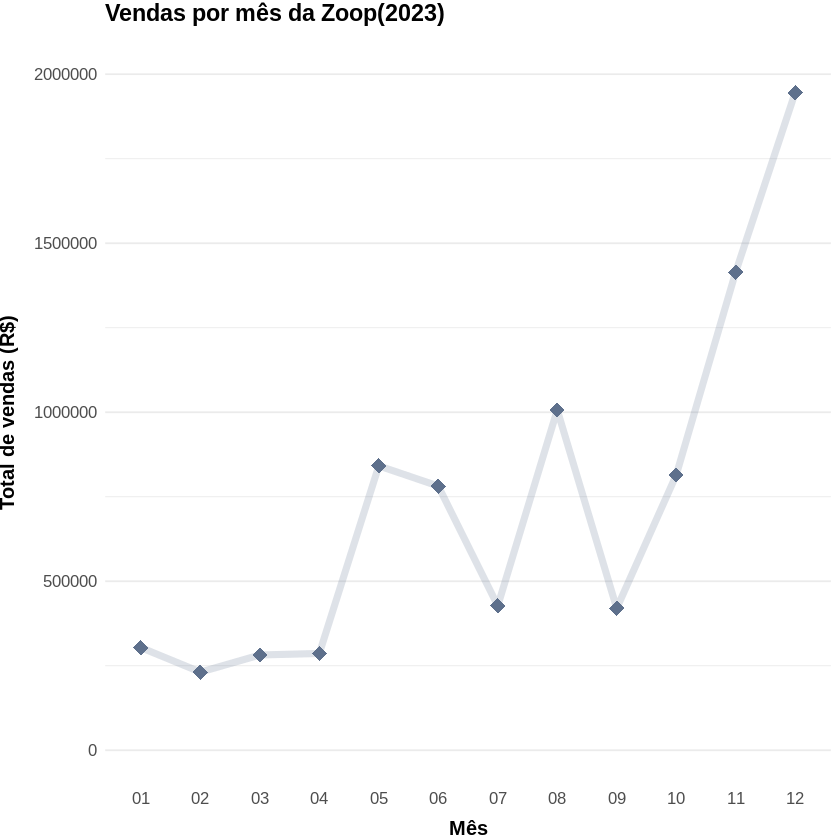

In [147]:
grafico_vendas_mes <- grafico_vendas_mes +
  tema +
  labs(title = "Vendas por mês da Zoop(2023)",
  x = "Mês",
  y = "Total de vendas (R$)")

grafico_vendas_mes

In [148]:
meses <- c("Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
           "Jul", "Ago", "Set", "Out", "Nov", "Dez")

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


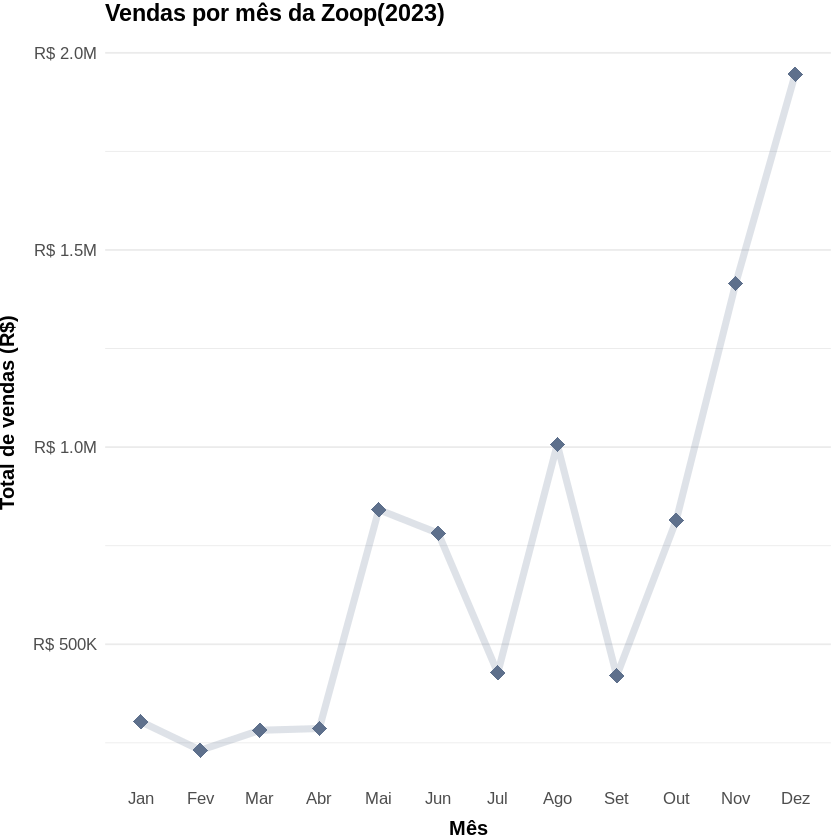

In [149]:
grafico_vendas_mes <- grafico_vendas_mes +
  scale_x_discrete(labels = meses) +
  scale_y_continuous(labels = label_number(prefix = "R$ ",
                                            scale_cut = cut_short_scale()))
grafico_vendas_mes

**Adicionando labels no visual**

In [150]:
grafico_vendas_categoria <-
  ggplot(vendas, aes(x = reorder(categoria, -total, FUN = sum), y = total)) +
    geom_col(fill = red_2) +
    scale_y_continuous(expand = c(0,0), limits = c(0, 5.2e6)) +
    coord_flip() +
    tema +
    labs(title = "Vendas por categoria da Zoop (2023)")

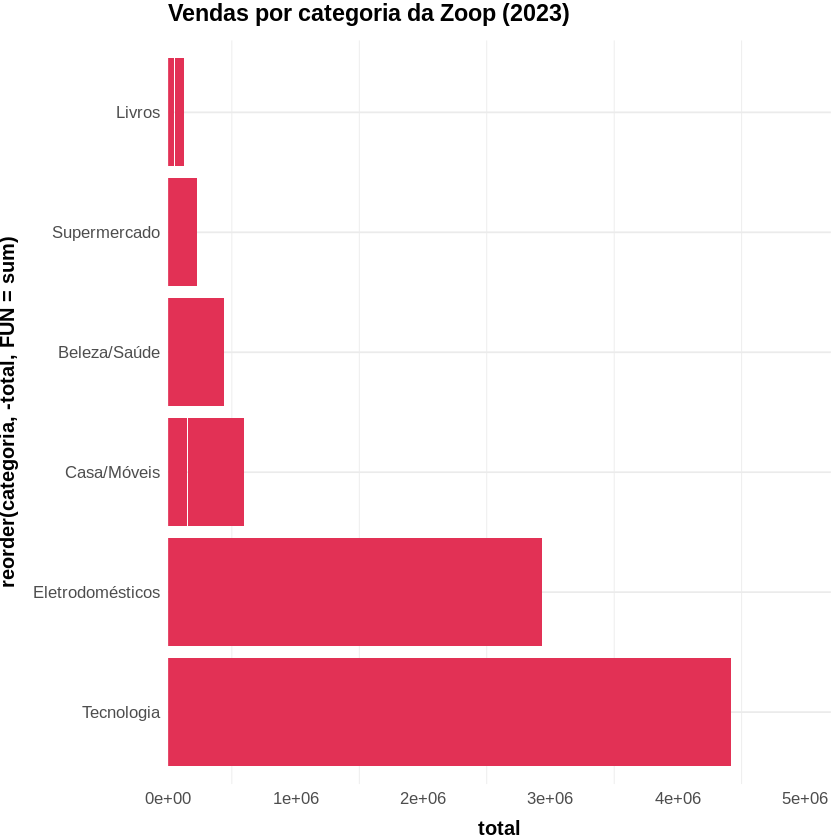

In [151]:
grafico_vendas_categoria

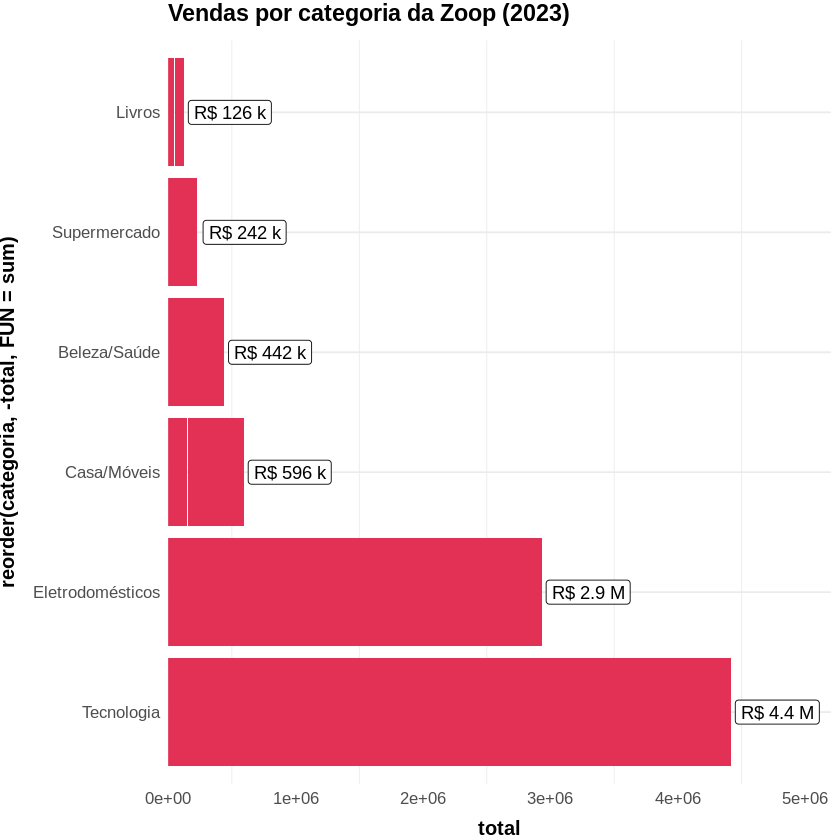

In [152]:
grafico_vendas_categoria <- grafico_vendas_categoria +
  geom_label(aes(label = number(after_stat(y),
                                prefix = "R$ ",
                                scale_cut = cut_si(""))),
            stat = 'summary', fun = "sum", hjust=-0.05)

grafico_vendas_categoria

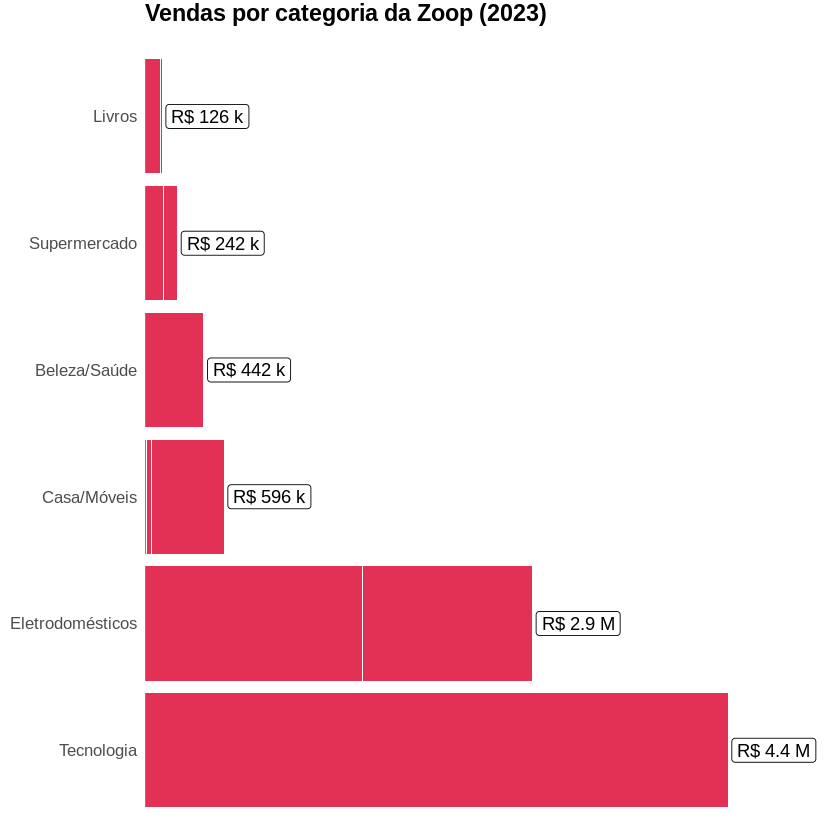

In [154]:
grafico_vendas_categoria <-
  grafico_vendas_categoria +
    theme(panel.grid = element_blank(),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        axis.text.x = element_blank())

grafico_vendas_categoria

# Concluindo o projeto

**Adicionando anotações no visual**

In [156]:
cores <- c(blue_1, blue_2, blue_3)

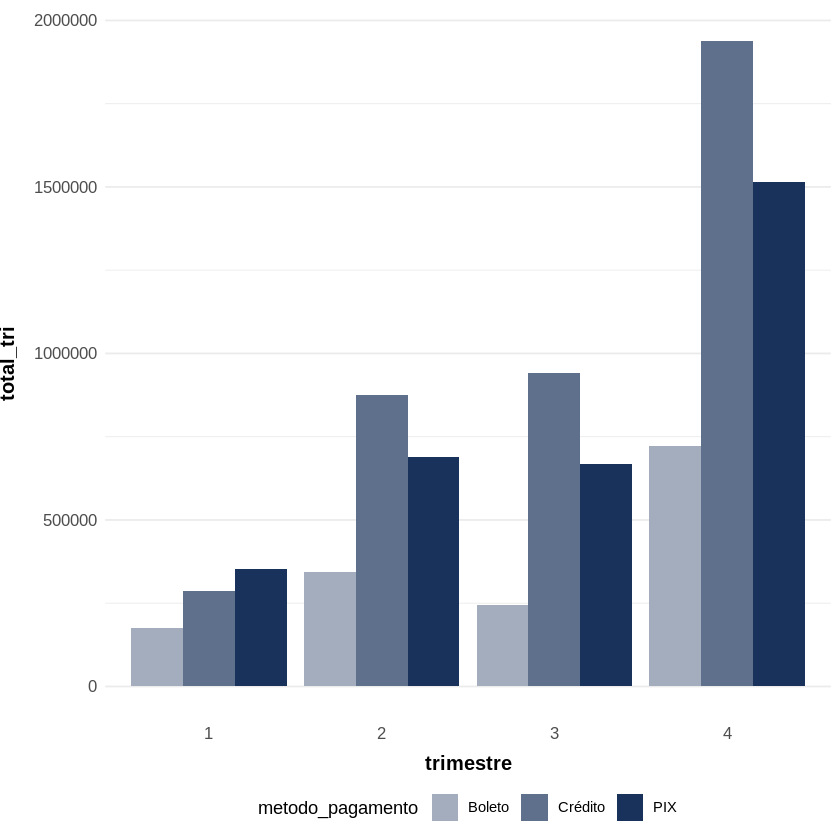

In [157]:
grafico_vendas_pag <-
  ggplot(vendas_por_tri, aes(trimestre, total_tri, fill = metodo_pagamento)) +
  geom_col(position = "dodge") +
  scale_fill_manual(values = cores) +
  tema

grafico_vendas_pag

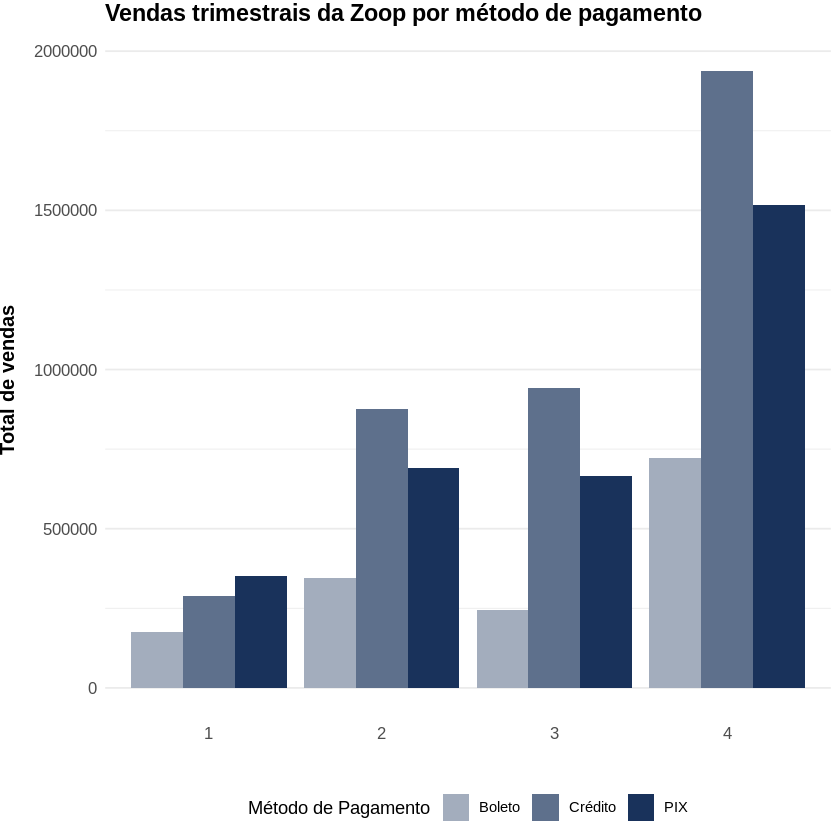

In [158]:
grafico_vendas_pag <- grafico_vendas_pag +
  labs(title = "Vendas trimestrais da Zoop por método de pagamento",
       x = "", y = "Total de vendas", fill = "Método de Pagamento")

grafico_vendas_pag

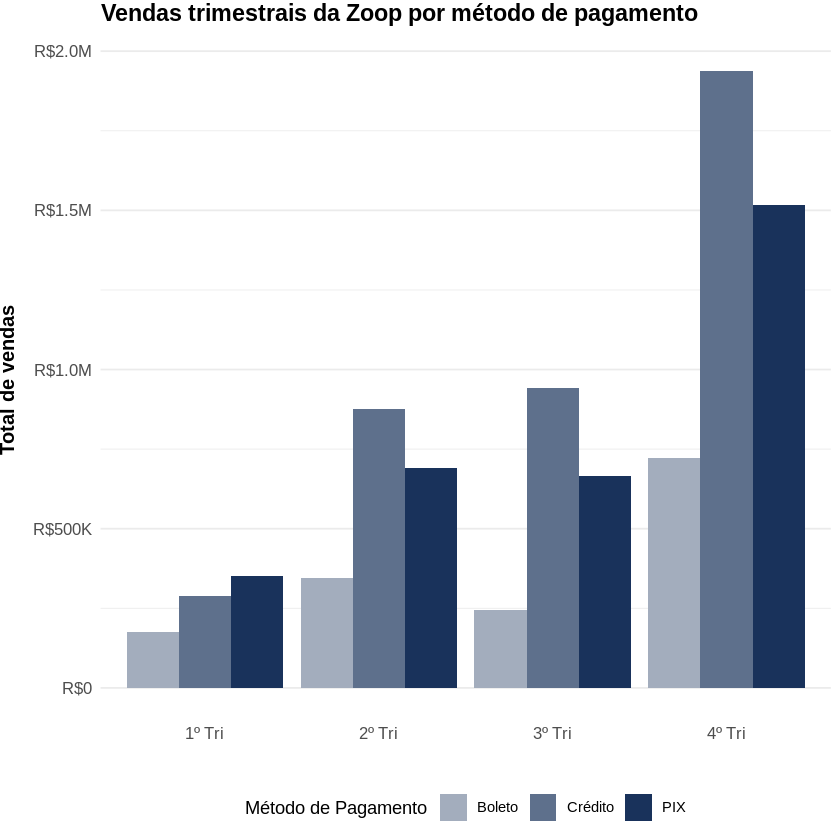

In [159]:
grafico_vendas_pag <- grafico_vendas_pag +
  scale_x_discrete(labels = c("1º Tri", "2º Tri", "3º Tri", "4º Tri")) +
  scale_y_continuous(labels = label_number(prefix = "R$",
                                            scale_cut = cut_short_scale()))

grafico_vendas_pag

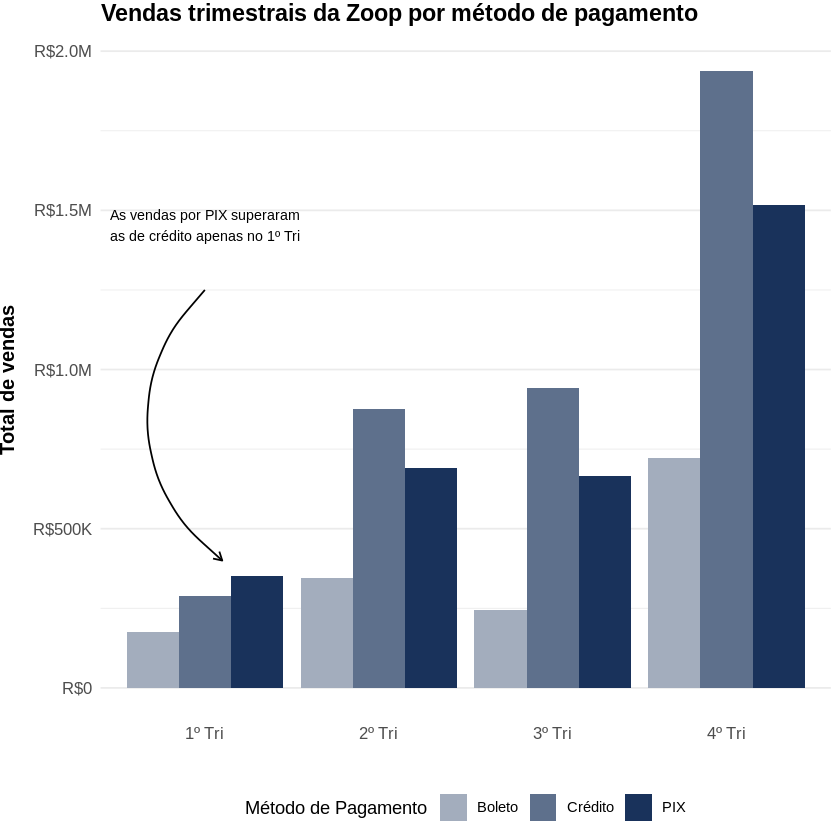

In [160]:
grafico_vendas_pag <- grafico_vendas_pag +
  annotate("text",
            x = 1 ,
            y = 1.5e6 ,
            label = "As vendas por PIX superaram\nas de crédito apenas no 1º Tri",
            vjust = 1, size = 3) +
  annotate("curve",
            x = 1,
            y = 1.25e6,
            xend = 1.1,
            yend = 400e3,
            arrow = arrow(length = unit(2, "mm")))

grafico_vendas_pag

**Para saber mais: outras formas de anotação em gráfico**

Anotações em gráficos são elementos bastante apropriados para destacar informações importantes e facilitar a interpretação de visualizações de dados. No ggplot2, há diversas formas de realizar anotações em gráficos e, neste texto, traremos duas muito utilizadas que são as linhas de referência, com geom_vline() ou geom_hline(), e o uso de áreas destacadas com annotate("rect").

Essas anotações servem para adicionar contexto, destacar limites ou faixas de interesse, e guiar a atenção do público para aspectos específicos dos dados. O uso adequado dessas ferramentas pode transformar uma visualização simples em uma narrativa visual muito mais impactante. Agora, vamos explorar em detalhes cada uma dessas formas. Vamos lá!

**geom_vline() e geom_hline()**
As funções geom_vline() e geom_hline() adicionam, respectivamente, linhas verticais e horizontais a um gráfico. Elas são usadas para marcar referências importantes, como médias, medianas, limites de controle ou qualquer outro valor significativo nos eixos do gráfico.

* geom_vline(): Adiciona uma linha vertical ao longo de uma coordenada x específica.
* geom_hline(): Adiciona uma linha horizontal ao longo de uma coordenada y específica.
Ambas adicionam clareza ao gráfico, guiando o público para valores específicos de interesse.

Vamos novamente usar a base de dados gapminder, que pode ser facilmente exportada para o R, e criar um gráfico de dispersão mostrando a relação entre o PIB per capita (gdpPercap) e a expectativa de vida (lifeExp) em 2007 (último ano da base de dados). Vamos adicionar uma linha vertical marcando a mediana do PIB per capita e uma linha horizontal marcando a média global da expectativa de vida. Experimente o seguinte código:

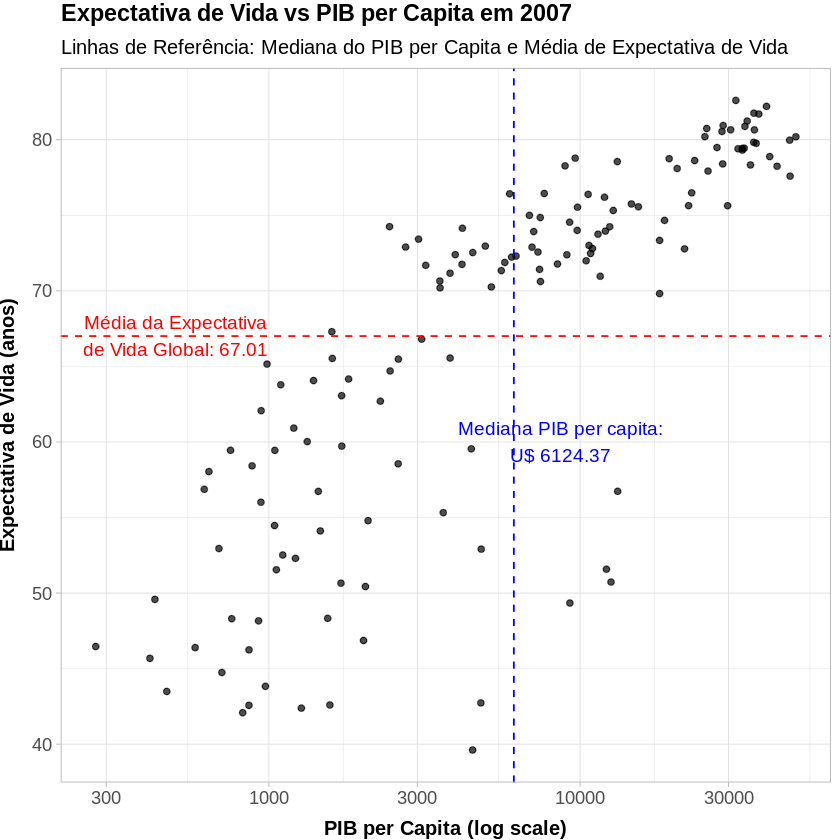

In [161]:
library(ggplot2)
library(dplyr)
library(gapminder)

# Filtrando os dados para o ano de 2007
gapminder_2007 <- gapminder %>%
  filter(year == 2007)

# Calculando a mediana do PIB per capita e a média da expectativa de vida
median_gdpPercap <- median(gapminder_2007$gdpPercap)
mean_lifeExp <- mean(gapminder_2007$lifeExp)

# Criando o gráfico com geom_vline() e geom_hline()
ggplot(gapminder_2007, aes(x = gdpPercap, y = lifeExp)) +
  geom_point(alpha = 0.7) +
  scale_x_log10() +  # Escala logarítmica no eixo x
  geom_vline(xintercept = median_gdpPercap, linetype = "dashed", color = "blue") +
  annotate("text", x = median_gdpPercap + 2.5e3, y = 60, label = paste("Mediana PIB per capita:\nU$", round(median_gdpPercap, 2)),
           color = "blue", size = 4) +
  geom_hline(yintercept = mean_lifeExp, linetype = "dashed", color = "red") +
  annotate("text", x = 500, y = mean_lifeExp, label = paste("Média da Expectativa\nde Vida Global:", round(mean_lifeExp, 2)),
           color = "red", size = 4) +
  labs( title = "Expectativa de Vida vs PIB per Capita em 2007",
        subtitle = "Linhas de Referência: Mediana do PIB per Capita e Média de Expectativa de Vida",
        x = "PIB per Capita (log scale)",
        y = "Expectativa de Vida (anos)") +
  theme_light() +
  theme(plot.title = element_text(size=14, face="bold", vjust = +2),
        plot.subtitle = element_text(size=12, vjust = +1),
        axis.text = element_text(size = 11),
        axis.title.x = element_text(size = 12, face = "bold", vjust = -1),
        axis.title.y = element_text(size = 12, face = "bold", vjust = +3))

A linha vertical azul marca a mediana do PIB per capita.
A linha horizontal vermelha marca a média global da expectativa de vida.
Essas linhas ajudam o público a visualizar onde os dados estão posicionados em relação a essas métricas de referência, facilitando comparações.
annotate("rect")
A função annotate("rect") é usada para destacar áreas específicas de um gráfico, desenhando retângulos em torno de uma região de interesse. É útil para destacar intervalos de dados ou faixas de valores em ambos os eixos, tornando fácil visualizar as áreas de importância.

Em resumo, esta função:

* Permite criar áreas sombreadas ou marcadas no gráfico.
* Ideal para destacar faixas de valores ou intervalos críticos.
* Adiciona contexto visual para identificar zonas de atenção, como áreas de risco, áreas de exceção, ou intervalos-alvo.

Neste exemplo, vamos destacar uma dada área de PIB per capita e expectativa de vida utilizando a função annotate("rect"). O gráfico também será baseado nos dados de 2007. Experimente o seguinte código:

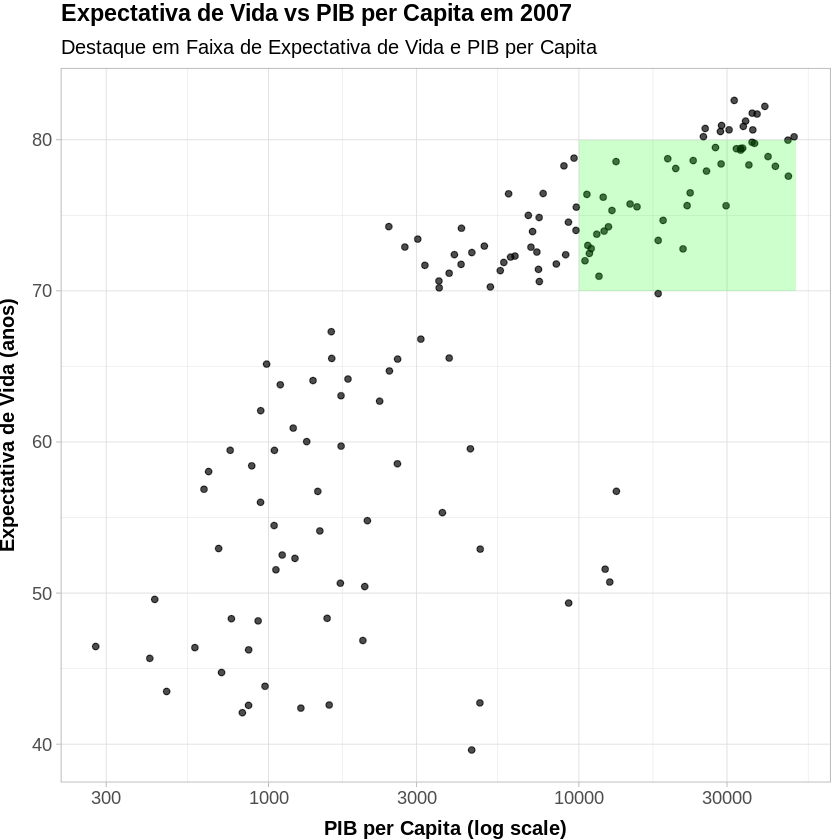

In [162]:
ggplot(gapminder_2007, aes(x = gdpPercap, y = lifeExp)) +
  geom_point(alpha = 0.7) +
  scale_x_log10() +  # Escala logarítmica no eixo x
  annotate("rect", xmin = 10000, xmax = 50000, ymin = 70, ymax = 80,
           alpha = 0.2, fill = "green") +
  labs(
    title = "Expectativa de Vida vs PIB per Capita em 2007",
    subtitle = "Destaque em Faixa de Expectativa de Vida e PIB per Capita",
    x = "PIB per Capita (log scale)",
    y = "Expectativa de Vida (anos)"
  ) +
  theme_light() +
  theme(plot.title = element_text(size=14, face="bold", vjust = +2),
        plot.subtitle = element_text(size=12, vjust = +1),
        axis.text = element_text(size = 11),
        axis.title.x = element_text(size = 12, face = "bold", vjust = -1),
        axis.title.y = element_text(size = 12, face = "bold", vjust = +3))

* O retângulo verde destaca a área do gráfico onde o PIB per capita está entre U$10.000 e U$50.000, e a expectativa de vida está entre 70 e 80 anos.
* Conseguimos destacar uma faixa de valores que pode interessar a um estudo específico, como uma zona de "alta qualidade de vida" ou uma faixa-alvo de políticas públicas.



---


Conseguimos demonstrar o potencial das anotações para adicionar contexto e clareza a visualizações de dados. Resumindo, as linhas de referência (geom_vline() e geom_hline()) ajudam a destacar valores-chave, como médias ou limites, enquanto áreas destacadas com annotate("rect") permitem identificar visualmente faixas de valores críticas.

Utilizando as anotações de forma consciente, evitando sobreposição aos dados ou uma carga cognitiva alta na interpretação dos visuais, podemos orientar nosso público nos aspectos mais importantes do gráfico. Isso torna as visualizações mais informativas e acessíveis.


**Salvando visuais**

In [164]:

ggsave("grafico_vendas_mes.png", grafico_vendas_mes,
       height = 5, width = 7, dpi=300)
ggsave("grafico_vendas_categoria.png", grafico_vendas_categoria,
       height = 5, width = 7, dpi=300)
ggsave("grafico_vendas_pag.png", grafico_vendas_pag,
       height = 5, width = 7, dpi=300)